## **IMPORTS**

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
import random
import os
from dotenv import load_dotenv

import src.experiments.config as cfg_module
import src.env.station as st
import src.env.car as car_module
import src.env.society as sct
import src.experiments.simulation as sim_module
import src.experiments.simulation_greedy as sim_greedy
from src.experiments.run import define_agents
from src.metric.plots_metrics import *

pygame 2.6.1 (SDL 2.28.4, Python 3.12.0)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
load_dotenv()

ROOT_PATH = os.getenv("ROOT_PATH")
OUTPUT_DIR = 'outputs'
OUTPUT_PATH = f'{ROOT_PATH}/{OUTPUT_DIR}'
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f'---> outputs logs in: {OUTPUT_PATH}')

---> outputs logs in: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs


## **UTILS**

### **CONFIG**

In [4]:
# --- CONFIG FUNCTION

def notebook_config(
    total_time=None,
    nb_car=None,
    nb_society=None,
    nb_station=None,
    base_car_behavior=None,
    station_strategy_noise=None,
    log_iter=None
):
    """
    Crée et configure un objet SimulationConfig
    pour les notebooks/tests.
    """

    config = cfg_module.SimulationConfig()

    # ------------------------------------------------ VISUALISATION
    config.set_VISUALIZE(False)

    # ------------------------------------------------ TEMPS
    if total_time is not None:
        config.set_TOTAL_TIME(total_time)

    if log_iter is not None:
        config.set_log_iter(log_iter)

    # ------------------------------------------------ AGENTS
    if nb_car is not None:

        if type(nb_car) is not int:
            raise TypeError(
                f"nb_car doit être un int, reçu : {type(nb_car).__name__}"
            )

        if nb_car <= 0:
            raise ValueError("nb_car doit être > 0")

        config.NB_CARS = nb_car

    if nb_society is not None:

        if type(nb_society) is not int:
            raise TypeError(
                f"nb_society doit être un int, reçu : {type(nb_society).__name__}"
            )

        if nb_society <= 0:
            raise ValueError("nb_society doit être > 0")

        config.NB_SOCIETIES = nb_society

    if nb_station is not None:

        if type(nb_station) is not int:
            raise TypeError(
                f"nb_station doit être un int, reçu : {type(nb_station).__name__}"
            )

        if nb_station <= 0:
            raise ValueError("nb_station doit être > 0")

        config.NB_STATIONS = nb_station

    # ------------------------------------------------ COMPORTEMENTS VOITURES
    if base_car_behavior is not None:

        required_keys = {
            'pres',
            'abs',
            'early',
            'late',
            'noise'
        }

        missing = required_keys - set(base_car_behavior.keys())

        if missing:
            raise ValueError(
                f"Clés manquantes dans base_car_behavior : {missing}"
            )

        total_prob = (
            base_car_behavior['pres']
            + base_car_behavior['abs']
            + base_car_behavior['early']
            + base_car_behavior['late']
        )

        if total_prob != 100:
            raise ValueError(
                f"La somme des probabilités doit valoir 100, reçu : {total_prob}"
            )

        config.BASE_CANCEL_PROB = base_car_behavior.copy()

    # ------------------------------------------------ BRUIT STRATÉGIE STATION
    if station_strategy_noise is not None:

        if not isinstance(station_strategy_noise, (int, float)):
            raise TypeError(
                "station_strategy_noise doit être numérique"
            )

        if station_strategy_noise < 0:
            raise ValueError(
                "station_strategy_noise doit être >= 0"
            )

        config.STRATEGY_NOISE = float(station_strategy_noise)

    return config

In [5]:
# --- EXAMPLE

total_time = 12 * 24 * 1  # une journée
log_iter = 12

nb_car = 50
nb_society = 4
nb_station = 40

strategy_noise = 0.5  # variation proportionnelle ±50%

base_car_behavior = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

c = notebook_config(total_time=total_time, nb_car=nb_car, nb_society=nb_society,
                nb_station=nb_station, base_car_behavior=base_car_behavior,
                station_strategy_noise=strategy_noise, log_iter=log_iter)

slot_h = c.SLOT_DURATION / 60
dist_slot = c.CAR_SPEED          # m/slot
autonomy_mean = c.CAR_AUTONOMY_PARAMS_KM['mean']
conso = c.ENERGY_CONSUMPTION['quantity_kW'] / c.ENERGY_CONSUMPTION['distance_unit_m']
delta_soc = dist_slot * conso / (c.ENERGY_CONSUMPTION['quantity_kW'] * autonomy_mean / 100)

print(f"Grille            : {c.C_GRID/1e3:.1f} km × {c.C_GRID/1e3:.1f} km")
print(f"Vitesse           : {c.CAR_SPEED} m/slot  ({c.CAR_SPEED/1000/slot_h:.0f} km/h)")
print(f"ΔSoC / slot       : {delta_soc:.5f}  ({1/delta_soc:.0f} slots pour vider)")
print(f"Autonomie moy.    : {autonomy_mean} km")
print(f"Distance max grille traversée avec soc=0.10 : {0.10*autonomy_mean:.0f} km >> {c.C_GRID/1e3:.1f} km ✓")


Grille            : 3.0 km × 3.0 km
Vitesse           : 4167.0 m/slot  (50 km/h)
ΔSoC / slot       : 0.01042  (96 slots pour vider)
Autonomie moy.    : 400 km
Distance max grille traversée avec soc=0.10 : 40 km >> 3.0 km ✓


### **CHARTS**

#### *Demand Satisfaction*

In [6]:
def plot_exact_needs_comparison(exact_values, needs_values, labels, colors,
                                scenario_name, nb_car):

    # Création des graphiques côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Graphique Exact --------
    bars1 = axes[0].bar(labels, exact_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Exact Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[0].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Graphique Needs --------
    bars2 = axes[1].bar(labels, needs_values, color=colors, alpha=0.7)
    

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Needs Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[1].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Travel & Waiting*

In [7]:
def plot_travel_waiting_comparison(travel_values, waiting_values, labels, colors,
                                scenario_name, nb_car):

    # Création des subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Travel Distance --------
    bars1 = axes[0].bar(labels, travel_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Travel Distance (km)', fontweight='bold')
    axes[0].set_ylabel('Distance (km)')
    axes[0].set_ylim(top = 1.15 * max(travel_values))

    # Valeurs sur les barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Waiting Time --------
    bars2 = axes[1].bar(labels, waiting_values, color=colors, alpha=0.7)

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Waiting Time (min)', fontweight='bold')
    axes[1].set_ylabel('Time (min)')
    if max(waiting_values) > 0.:
        axes[1].set_ylim(top = 1.15 * max(waiting_values))
    else:
        axes[1].set_ylim(bottom = 0. ,top = 5.)

    # Valeurs sur les barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Scalability*

In [8]:
def plot_mean_response_time_comparison(labels, colors, values, scenario_name, nb_car):

    fig, ax = plt.subplots(figsize=(6, 5))

    bars = ax.bar(labels, values, color=colors, alpha=0.8)

    scenario_tag = f"[{scenario_name[:3].upper()}@{nb_car}]"

    ax.set_title(
        f'{scenario_tag} Mean Response Time (ms)',
        fontweight='bold'
    )

    ax.set_ylabel('Response Time (ms)')

    if max(values) > 0:
        ax.set_ylim(0, 1.15 * max(values))

    # Affichage des valeurs
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01 * max(values),
            f'{height:.2f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Comparison*

In [9]:
def plot_metric_comparison(
    greedy_values,
    bramev_values,
    nb_car_list,
    ylabel,
    title,
    colors,
    scenario_name
):

    x = np.arange(len(nb_car_list))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    bars1 = ax.bar(
        x - width / 2,
        greedy_values,
        width,
        label='Greedy',
        color=colors[0],
        alpha=0.8
    )

    bars2 = ax.bar(
        x + width / 2,
        bramev_values,
        width,
        label='BRAMEV',
        color=colors[1],
        alpha=0.8
    )

    scenario_tag = f"[{scenario_name[:3].upper()}]"

    ax.set_title(
        f'{scenario_tag} {title}',
        fontweight='bold'
    )

    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(nb_car_list)
    ax.set_xlabel('Number of Cars')

    ax.legend()

    max_value = max(
        max(greedy_values),
        max(bramev_values)
    )

    if max_value > 0:
        ax.set_ylim(0, 1.15 * max_value)

    # Valeurs sur les barres
    for bars in [bars1, bars2]:

        for bar in bars:

            height = bar.get_height()

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.01 * max_value,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

    plt.tight_layout()
    plt.show()
    plt.close()


# =========================================================
# 1. Exact Satisfaction
# =========================================================

def plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        exact_satif_greedy_list,
        exact_satif_bramev_list,
        nb_car_list,
        ylabel='Satisfaction (%)',
        title='Exact Satisfaction (%)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 2. Needs Satisfaction
# =========================================================

def plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        needs_satif_greedy_list,
        needs_satif_bramev_list,
        nb_car_list,
        ylabel='Satisfaction (%)',
        title='Needs Satisfaction (%)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 3. Mean Travel Distance
# =========================================================

def plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_travel_greedy_list,
        mean_travel_bramev_list,
        nb_car_list,
        ylabel='Distance (km)',
        title='Mean Travel Distance (km)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 4. Mean Waiting Time
# =========================================================

def plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_waiting_greedy_list,
        mean_waiting_bramev_list,
        nb_car_list,
        ylabel='Waiting Time (min)',
        title='Mean Waiting Time (min)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 5. Mean Response Time
# =========================================================

def plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_response_greedy_list,
        mean_response_bramev_list,
        nb_car_list,
        ylabel='Response Time (ms)',
        title='Mean Response Time (ms)',
        colors=colors,
        scenario_name=scenario_name
    )
    

## **EXPERIMENTS**

### **GLOBAL CONFIG**

In [10]:
SCENARIO = 'optimistic'

BASE_CAR_BEHAVIOR = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

In [11]:
OUTPUT_FOLDER_PATH = f'{OUTPUT_PATH}/{SCENARIO}'
os.makedirs(OUTPUT_FOLDER_PATH, exist_ok=True)

print(f'Scenario outputs folders in folder: {OUTPUT_FOLDER_PATH}')

Scenario outputs folders in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic


In [12]:
TOTAL_TIME = 12 * 24 * 5  # 5 jours
LOG_ITER = 12             # 12 -> toutes les heures

NB_SOCIETY = 4
NB_STATION = 40

STRATEGY_NOISE = 0.5  # variation proportionnelle ±50%

In [13]:
nb_car_list = []

exact_satif_greedy_list, exact_satif_bramev_list = [], []
needs_satif_greedy_list, needs_satif_bramev_list = [], []
mean_travel_greedy_list, mean_travel_bramev_list = [], []
mean_waiting_greedy_list, mean_waiting_bramev_list = [], []
mean_response_greedy_list, mean_response_bramev_list = [], []

### **EVChargingManagement@50cars**

#### **CONFIG**

In [14]:
nb_car = 50
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [15]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/50cars


##### *Initialisation*

In [16]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [17]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-25 22:28:41.064 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-25 22:28:41.179 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-25 22:28:41.240 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-25 22:28:41.318 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-25 22:28:41.386 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-25 22:28:41.441 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-25 22:28:41.586 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-25 22:28:41.615 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-25 22:28:41.678 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-25 22:28:41.785 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-25 22:28:41.839 | IN

##### *Metrics*

In [18]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 2.13 kWh
  Station 1: 0.00 kWh
  Station 2: 1.20 kWh
  Station 3: 0.00 kWh
  Station 4: 2.61 kWh
  Station 5: 9.08 kWh
  Station 6: 4.60 kWh
  Station 7: 0.00 kWh
  Station 8: 26.04 kWh
  Station 9: 3.95 kWh
  Station 10: 4.83 kWh
  Station 11: 1.80 kWh
  Station 12: 8.57 kWh
  Station 13: 4.68 kWh
  Station 14: 0.00 kWh
  Station 15: 4.35 kWh
  Station 16: 100.91 kWh
  Station 17: 5.32 kWh
  Station 18: 1.97 kWh
  Station 19: 5.81 kWh
  Station 20: 7.33 kWh
  Station 21: 16.70 kWh
  Station 22: 15.58 kWh
  Station 23: 3.92 kWh
  Station 24: 0.00 kWh
  Station 25: 31.27 kWh
  Station 26: 0.00 kWh
  Station 27: 63.99 kWh
  Station 28: 2.43 kWh
  Station 29: 3.95 kWh
  Station 30: 0.00 kWh
  Station 31: 0.00 kWh
  Station 32: 19.24 kWh
  Station 33: 2.29 kWh
  Station 34: 24.34 kWh
  Station 35: 0.00 kWh
  Station 36: 7.06 kWh
  Station 37: 95.58 kWh
  Station 38: 9.45 kWh
  Station 39: 65.07 kWh

--- User Reques

In [19]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

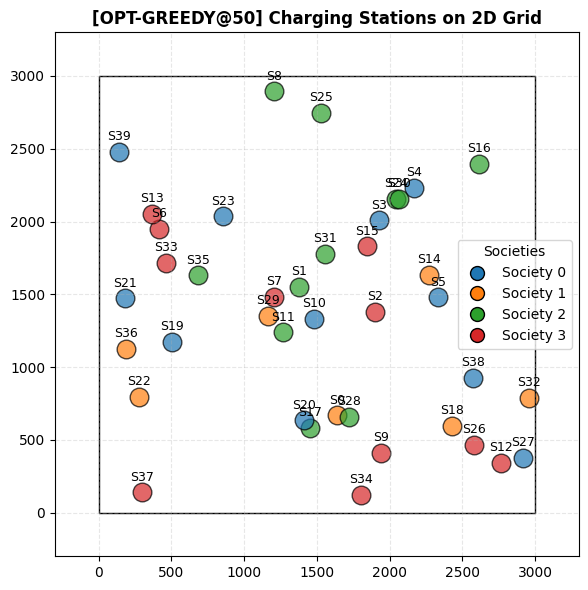

In [20]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=300)

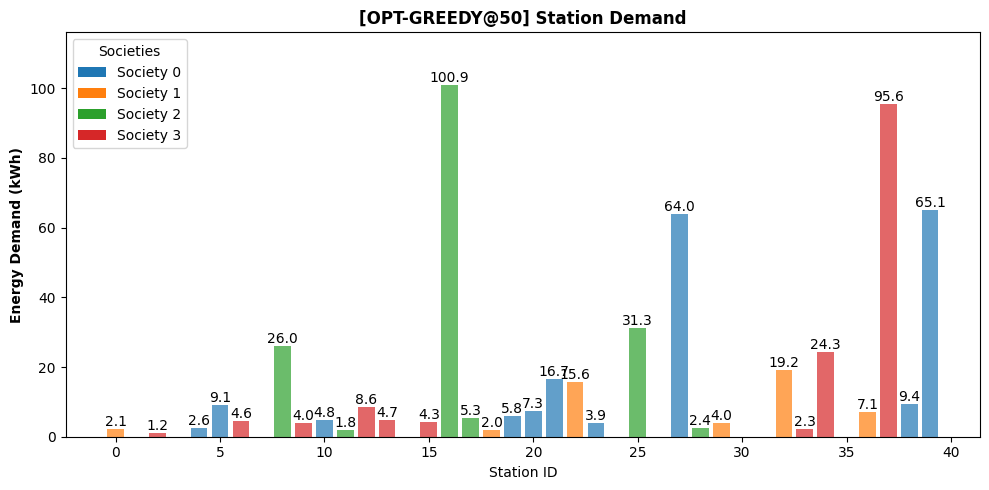

In [21]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

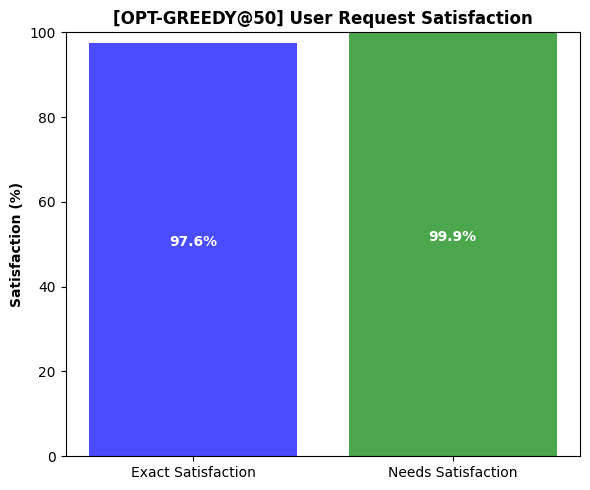

In [22]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

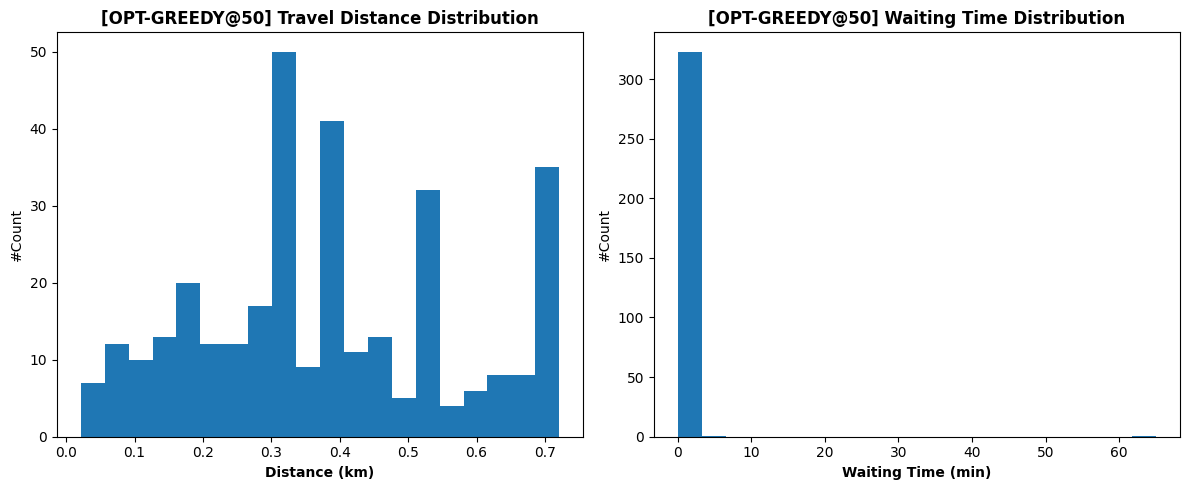

In [23]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

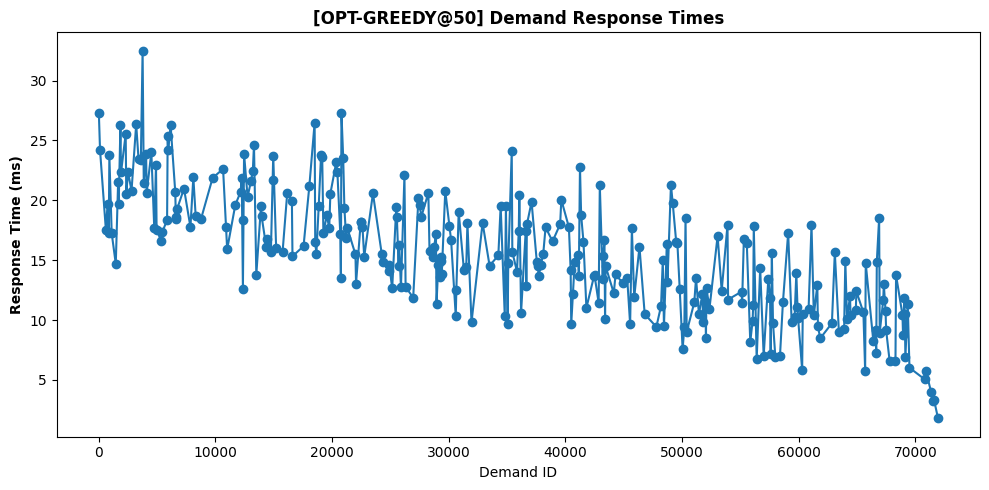

In [24]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

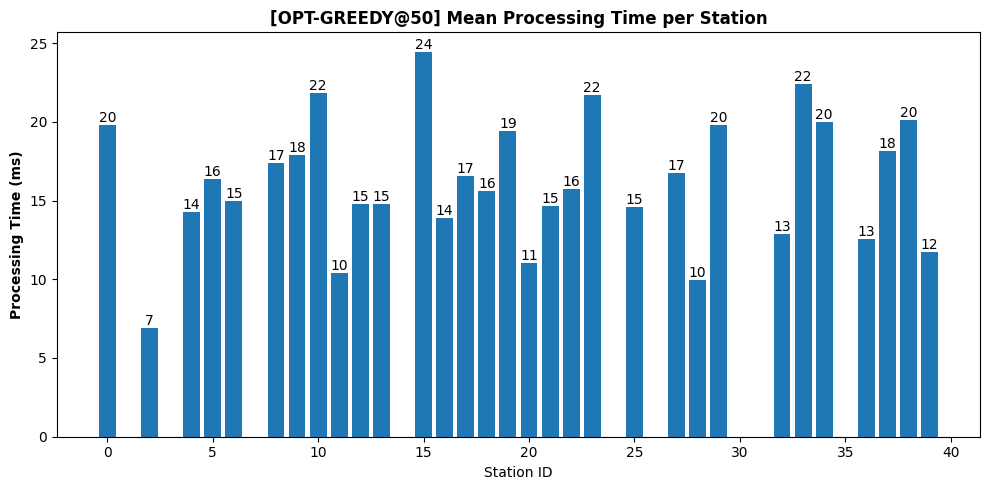

In [25]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [ ]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/50cars


##### *Initialisation*

In [ ]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [ ]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-25 21:52:01.659 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-25 21:52:02.087 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-25 21:52:02.598 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-25 21:52:02.701 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-25 21:52:02.962 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-25 21:52:03.570 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-25 21:52:03.864 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-25 21:52:04.592 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-25 21:52:04.975 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-25 21:52:05.508 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-25 21:52:05.790 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [ ]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 1.98 kWh
  Station 1: 1.80 kWh
  Station 2: 0.00 kWh
  Station 3: 19.07 kWh
  Station 4: 6.85 kWh
  Station 5: 8.25 kWh
  Station 6: 15.59 kWh
  Station 7: 4.67 kWh
  Station 8: 81.82 kWh
  Station 9: 2.21 kWh
  Station 10: 0.00 kWh
  Station 11: 20.88 kWh
  Station 12: 74.33 kWh
  Station 13: 1.60 kWh
  Station 14: 14.03 kWh
  Station 15: 10.23 kWh
  Station 16: 20.58 kWh
  Station 17: 3.59 kWh
  Station 18: 64.96 kWh
  Station 19: 5.43 kWh
  Station 20: 1.40 kWh
  Station 21: 45.52 kWh
  Station 22: 5.77 kWh
  Station 23: 1.93 kWh
  Station 24: 9.62 kWh
  Station 25: 1.38 kWh
  Station 26: 5.47 kWh
  Station 27: 1.50 kWh
  Station 28: 2.13 kWh
  Station 29: 0.00 kWh
  Station 30: 2.53 kWh
  Station 31: 6.95 kWh
  Station 32: 3.63 kWh
  Station 33: 7.22 kWh
  Station 34: 0.00 kWh
  Station 35: 78.18 kWh
  Station 36: 16.82 kWh
  Station 37: 1.34 kWh
  Station 38: 10.74 kWh
  Station 39: 7.61 kWh

--- User Requ

In [ ]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

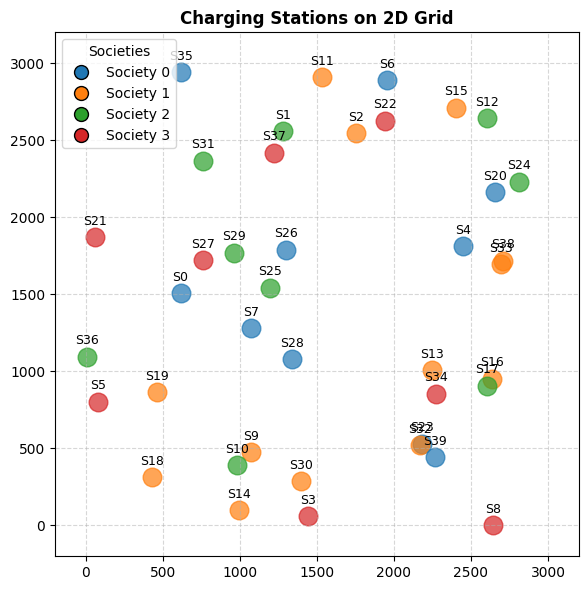

In [ ]:
plot_stations_2d(stations, sim_config, figsize=(6, 6), padding=200)

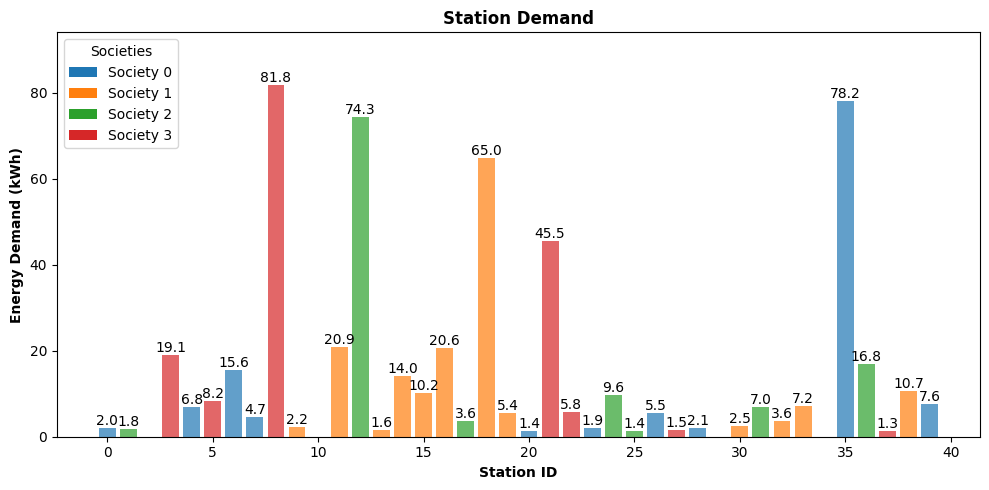

In [ ]:
plot_station_demand(simulation.metrics, societies=societies, figsize=(10, 5))

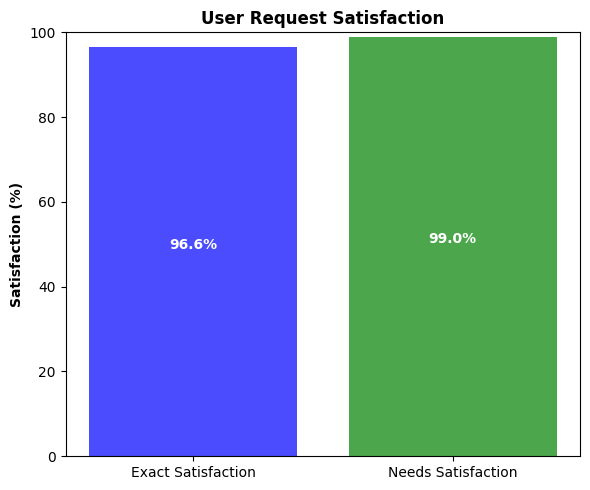

In [ ]:
plot_user_satisfaction(simulation.metrics)

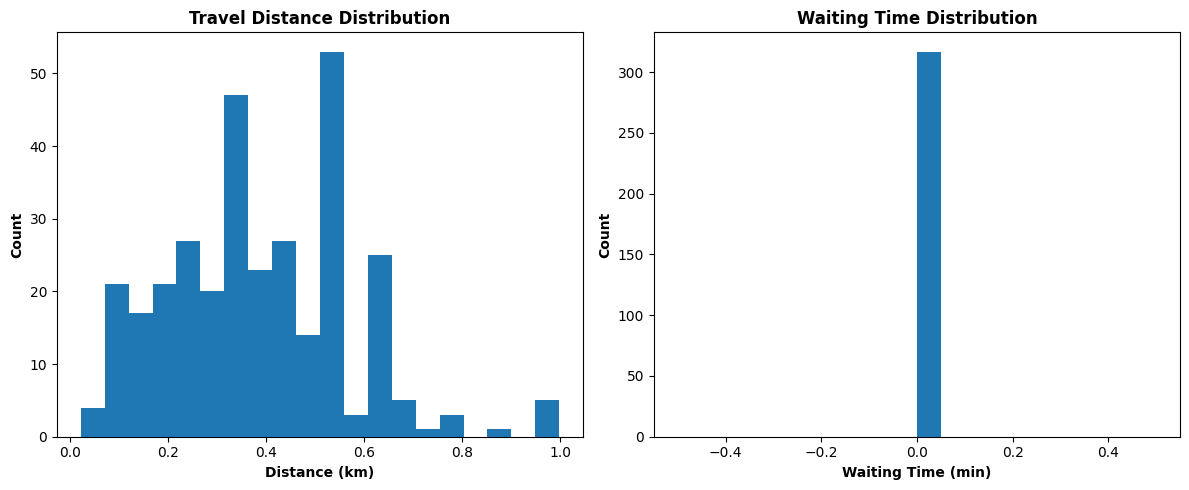

In [ ]:
plot_travel_waiting(simulation.metrics)

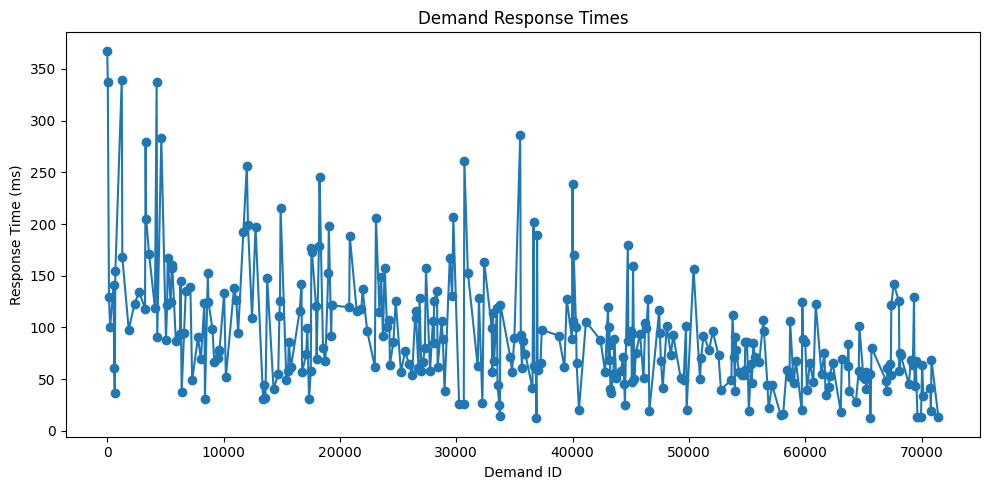

In [ ]:
plot_response_times(simulation.metrics)

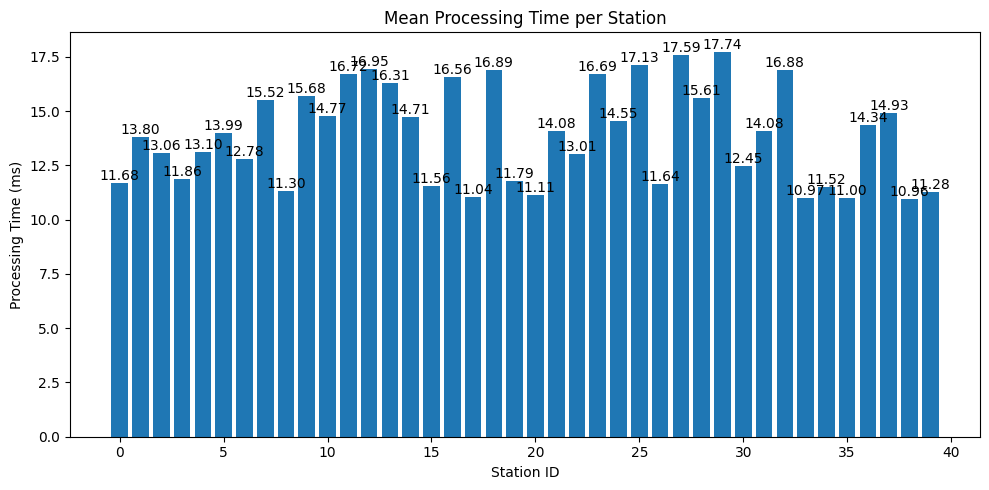

In [ ]:
plot_processing_times(simulation.metrics)

#### **COMPARISON**

##### *Params*

In [ ]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

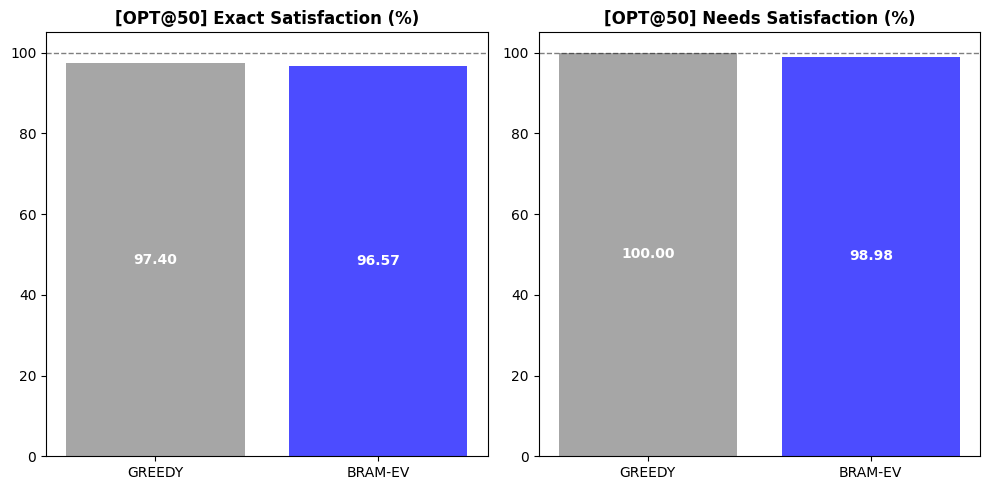

In [ ]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

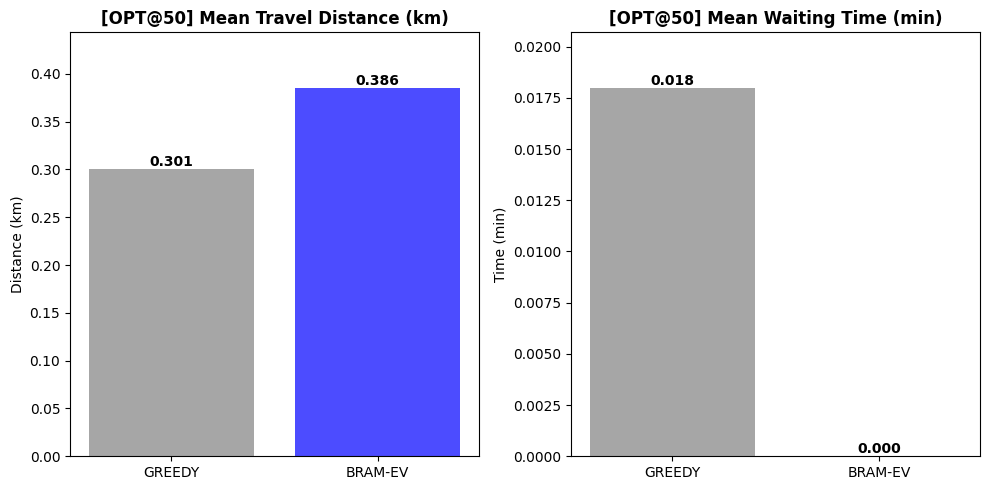

In [ ]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

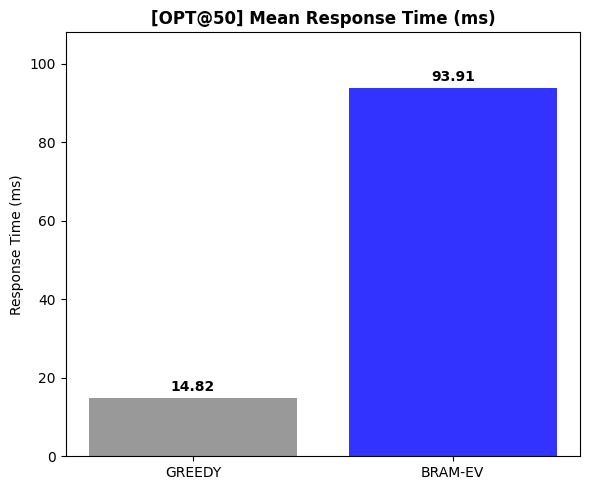

In [ ]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@100cars**

#### **CONFIG**

In [41]:
nb_car = 100
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [42]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/100cars


##### *Initialisation*

In [43]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [44]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-25 21:52:31.265 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-25 21:52:31.315 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-25 21:52:31.381 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-25 21:52:31.549 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-25 21:52:31.728 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-25 21:52:31.893 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-25 21:52:32.051 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-25 21:52:32.172 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-25 21:52:32.317 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-25 21:52:32.478 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-25 21:52:32.607 | IN

##### *Metrics*

In [45]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 28.00 kWh
  Station 1: 40.44 kWh
  Station 2: 0.00 kWh
  Station 3: 8.24 kWh
  Station 4: 82.54 kWh
  Station 5: 155.83 kWh
  Station 6: 32.14 kWh
  Station 7: 0.00 kWh
  Station 8: 42.66 kWh
  Station 9: 2.29 kWh
  Station 10: 4.72 kWh
  Station 11: 9.12 kWh
  Station 12: 127.85 kWh
  Station 13: 0.00 kWh
  Station 14: 3.65 kWh
  Station 15: 20.07 kWh
  Station 16: 5.17 kWh
  Station 17: 0.00 kWh
  Station 18: 36.40 kWh
  Station 19: 2.17 kWh
  Station 20: 0.00 kWh
  Station 21: 10.14 kWh
  Station 22: 0.00 kWh
  Station 23: 6.99 kWh
  Station 24: 5.14 kWh
  Station 25: 168.49 kWh
  Station 26: 27.12 kWh
  Station 27: 10.34 kWh
  Station 28: 2.73 kWh
  Station 29: 9.15 kWh
  Station 30: 0.00 kWh
  Station 31: 50.41 kWh
  Station 32: 30.84 kWh
  Station 33: 1.40 kWh
  Station 34: 151.51 kWh
  Station 35: 8.93 kWh
  Station 36: 13.72 kWh
  Station 37: 10.64 kWh
  Station 38: 3.01 kWh
  Station 39: 1.40 kWh

--- 

In [46]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

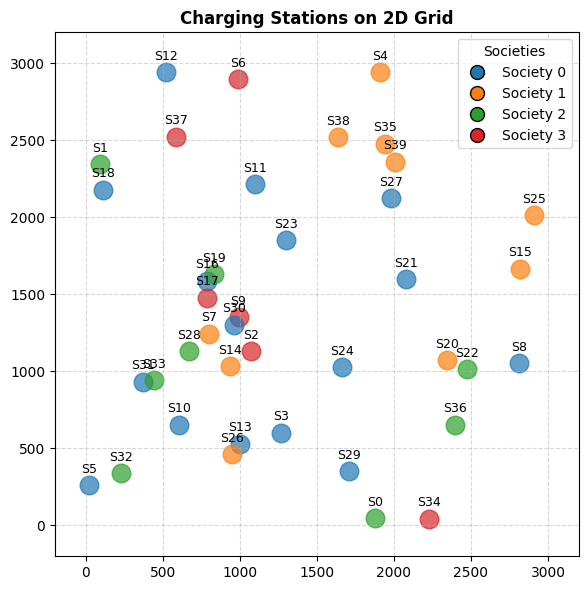

In [47]:
plot_stations_2d(stations, sim_config, figsize=(6, 6), padding=200)

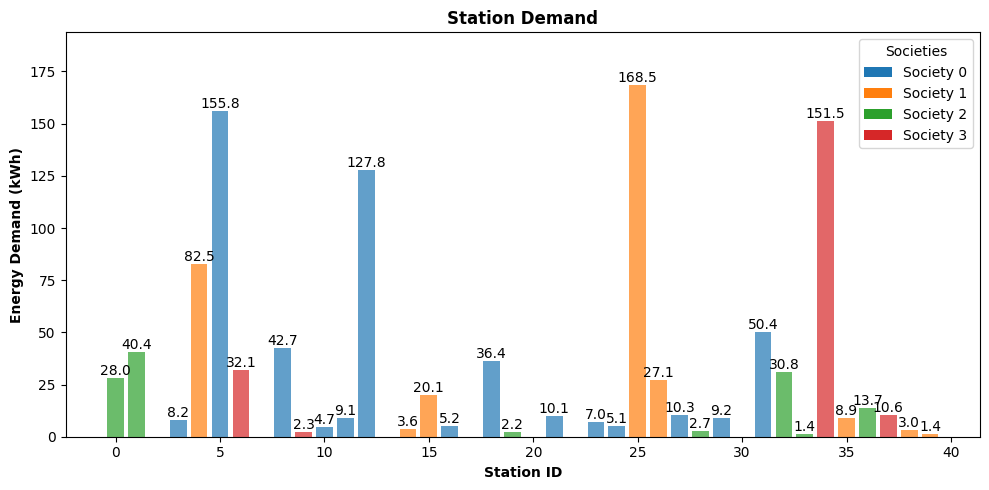

In [48]:
plot_station_demand(greedy_simulation.metrics, societies=societies, figsize=(10, 5))

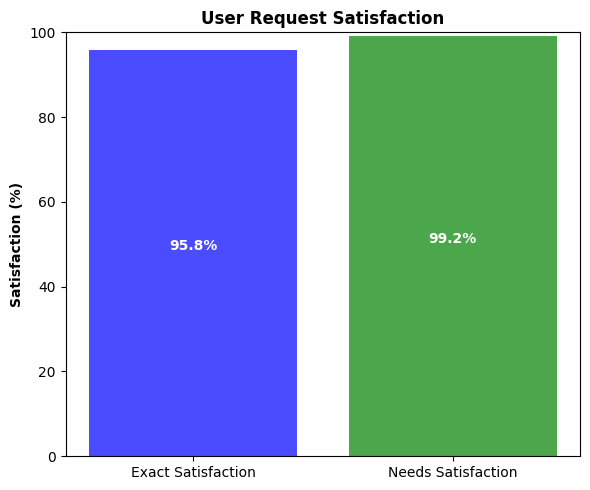

In [49]:
plot_user_satisfaction(greedy_simulation.metrics)

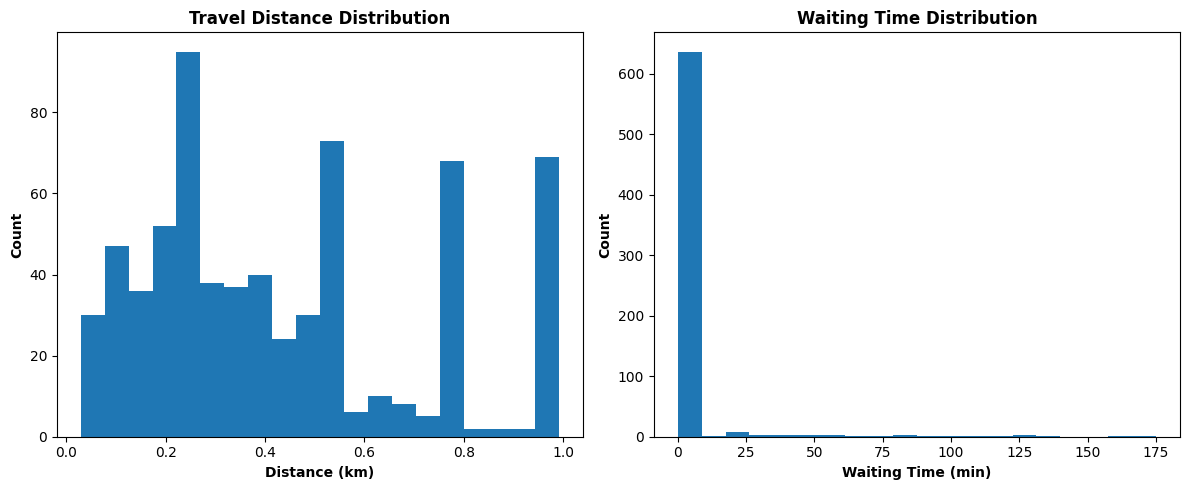

In [50]:
plot_travel_waiting(greedy_simulation.metrics)

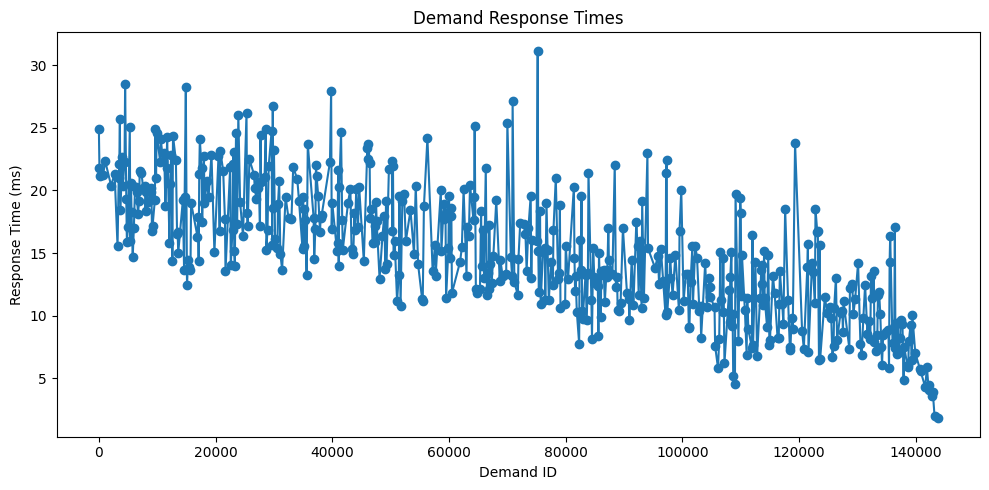

In [51]:
plot_response_times(greedy_simulation.metrics)

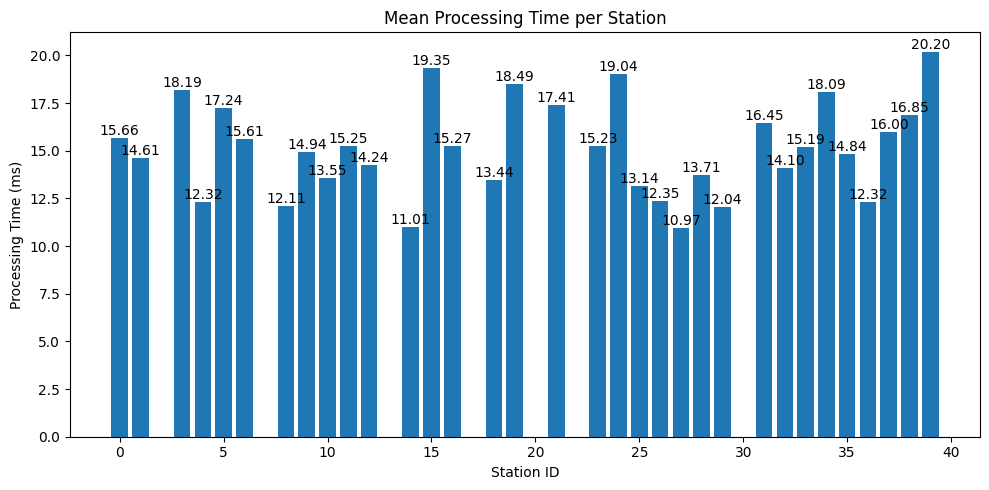

In [52]:
plot_processing_times(greedy_simulation.metrics)

#### **BRAM-EV**

##### *Params*

In [53]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/100cars


##### *Initialisation*

In [54]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [55]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-25 21:52:46.044 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-25 21:52:47.386 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-25 21:52:47.495 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-25 21:52:48.328 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-25 21:52:49.401 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-25 21:52:49.986 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-25 21:52:51.581 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-25 21:52:52.088 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-25 21:52:52.334 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-25 21:52:53.002 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-25 21:52:54.085 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [56]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 66.38 kWh
  Station 1: 9.53 kWh
  Station 2: 14.03 kWh
  Station 3: 1.23 kWh
  Station 4: 29.27 kWh
  Station 5: 34.94 kWh
  Station 6: 134.07 kWh
  Station 7: 6.20 kWh
  Station 8: 11.80 kWh
  Station 9: 29.12 kWh
  Station 10: 3.42 kWh
  Station 11: 3.02 kWh
  Station 12: 1.62 kWh
  Station 13: 133.97 kWh
  Station 14: 9.38 kWh
  Station 15: 9.47 kWh
  Station 16: 9.10 kWh
  Station 17: 34.53 kWh
  Station 18: 3.51 kWh
  Station 19: 3.42 kWh
  Station 20: 44.38 kWh
  Station 21: 127.73 kWh
  Station 22: 0.00 kWh
  Station 23: 14.32 kWh
  Station 24: 0.00 kWh
  Station 25: 9.08 kWh
  Station 26: 5.25 kWh
  Station 27: 1.33 kWh
  Station 28: 7.08 kWh
  Station 29: 0.00 kWh
  Station 30: 135.53 kWh
  Station 31: 36.88 kWh
  Station 32: 40.33 kWh
  Station 33: 27.51 kWh
  Station 34: 6.74 kWh
  Station 35: 49.70 kWh
  Station 36: 26.89 kWh
  Station 37: 10.14 kWh
  Station 38: 5.67 kWh
  Station 39: 21.31 kWh

--

In [57]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

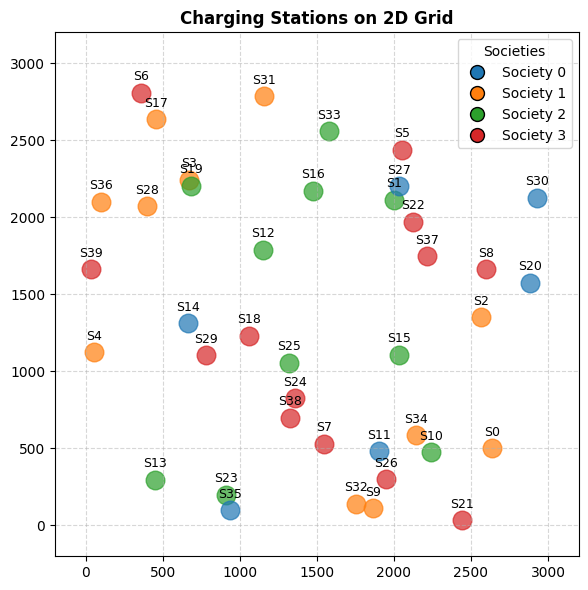

In [58]:
plot_stations_2d(stations, sim_config, figsize=(6, 6), padding=200)

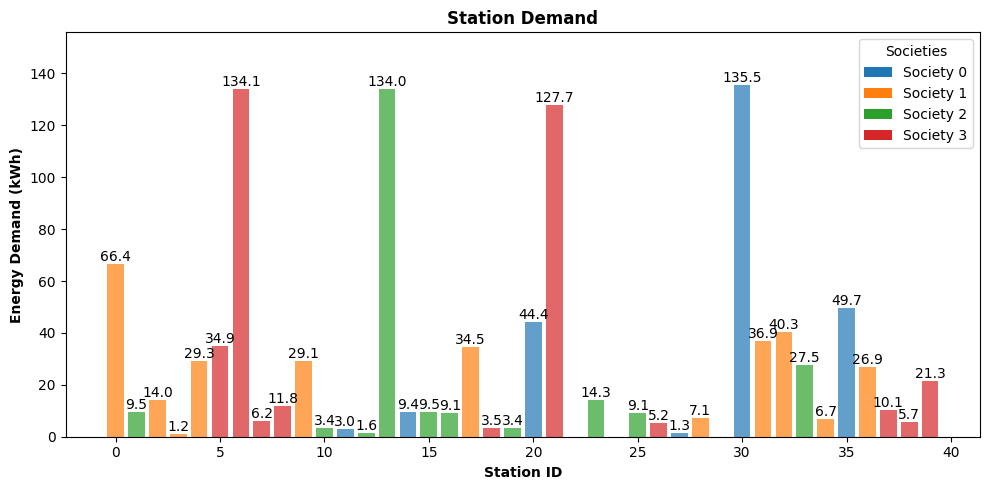

In [59]:
plot_station_demand(simulation.metrics, societies=societies, figsize=(10, 5))

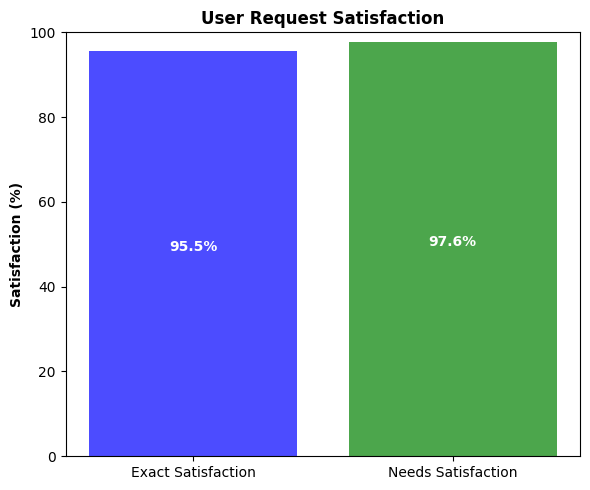

In [60]:
plot_user_satisfaction(simulation.metrics)

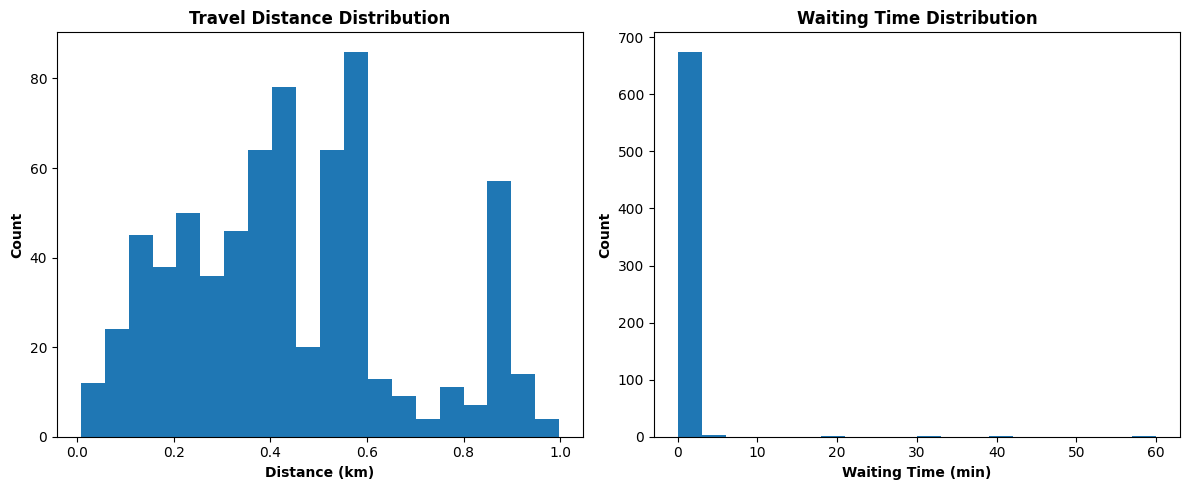

In [61]:
plot_travel_waiting(simulation.metrics)

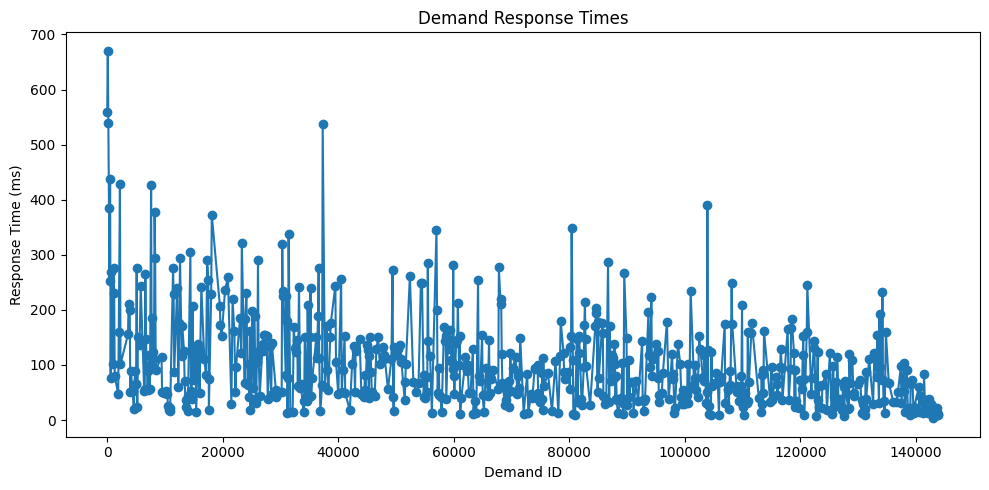

In [62]:
plot_response_times(simulation.metrics)

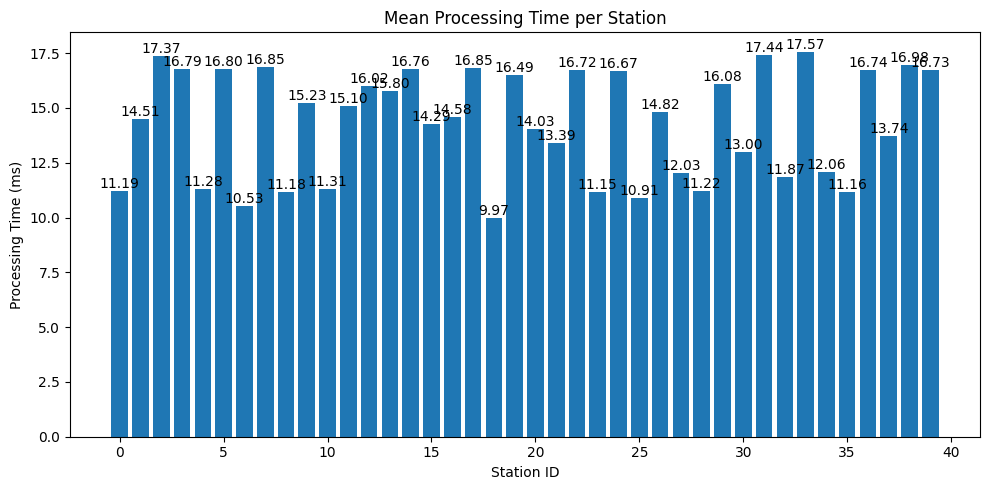

In [63]:
plot_processing_times(simulation.metrics)

#### **COMPARISON**

##### *Params*

In [64]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

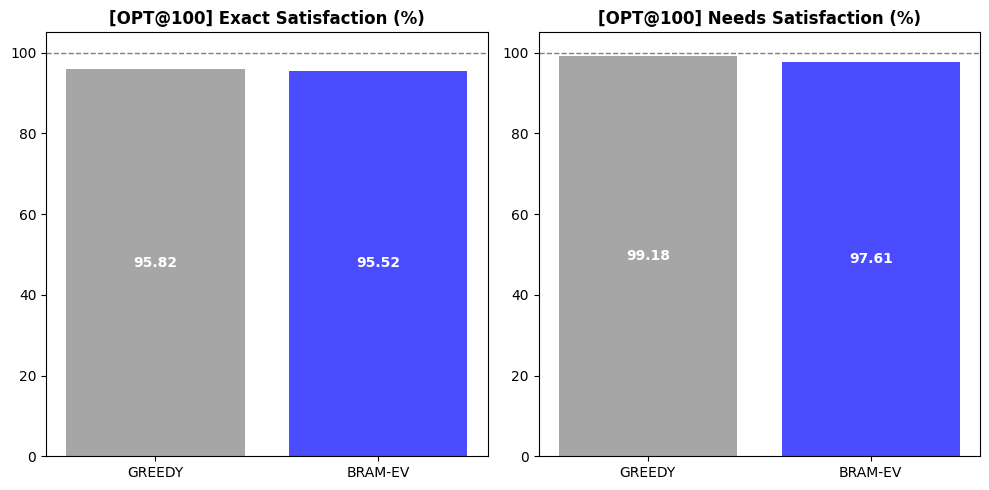

In [65]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

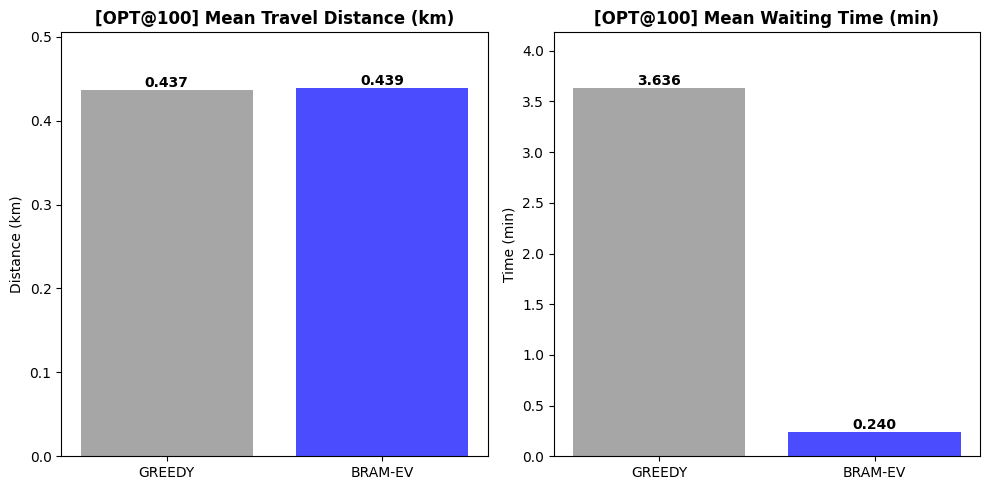

In [66]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

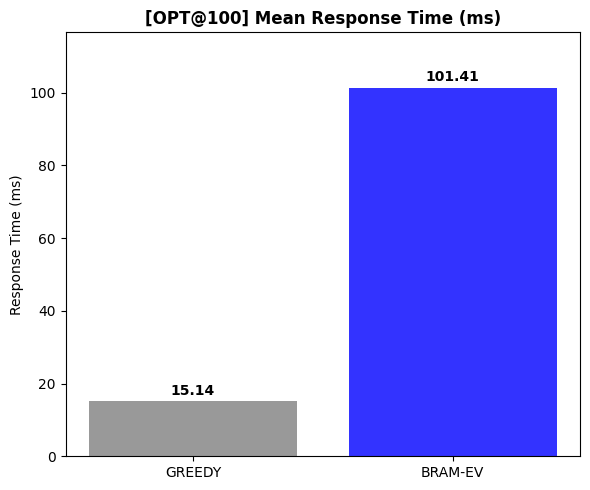

In [67]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@200cars**

#### **CONFIG**

In [68]:
nb_car = 200
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [69]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/200cars


##### *Initialisation*

In [70]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [71]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-25 21:53:49.896 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-25 21:53:50.164 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-25 21:53:50.418 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-25 21:53:50.800 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-25 21:53:51.159 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-25 21:53:51.355 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-25 21:53:51.565 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-25 21:53:51.857 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-25 21:53:52.175 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-25 21:53:52.447 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-25 21:53:52.624 | IN

##### *Metrics*

In [72]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 57.86 kWh
  Station 1: 13.96 kWh
  Station 2: 9.66 kWh
  Station 3: 8.87 kWh
  Station 4: 6.59 kWh
  Station 5: 84.32 kWh
  Station 6: 5.76 kWh
  Station 7: 15.23 kWh
  Station 8: 9.44 kWh
  Station 9: 11.73 kWh
  Station 10: 22.61 kWh
  Station 11: 41.03 kWh
  Station 12: 8.31 kWh
  Station 13: 10.67 kWh
  Station 14: 10.79 kWh
  Station 15: 24.69 kWh
  Station 16: 60.39 kWh
  Station 17: 6.44 kWh
  Station 18: 48.94 kWh
  Station 19: 56.76 kWh
  Station 20: 44.99 kWh
  Station 21: 251.12 kWh
  Station 22: 69.60 kWh
  Station 23: 3.13 kWh
  Station 24: 321.72 kWh
  Station 25: 51.12 kWh
  Station 26: 17.36 kWh
  Station 27: 108.15 kWh
  Station 28: 286.79 kWh
  Station 29: 16.27 kWh
  Station 30: 6.33 kWh
  Station 31: 222.29 kWh
  Station 32: 8.94 kWh
  Station 33: 7.96 kWh
  Station 34: 77.47 kWh
  Station 35: 57.72 kWh
  Station 36: 14.60 kWh
  Station 37: 42.92 kWh
  Station 38: 45.27 kWh
  Station 39: 12.

In [73]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

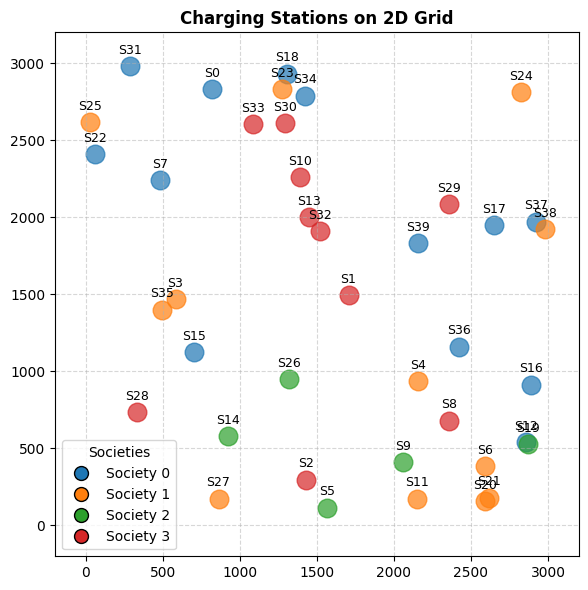

In [74]:
plot_stations_2d(stations, sim_config, figsize=(6, 6), padding=200)

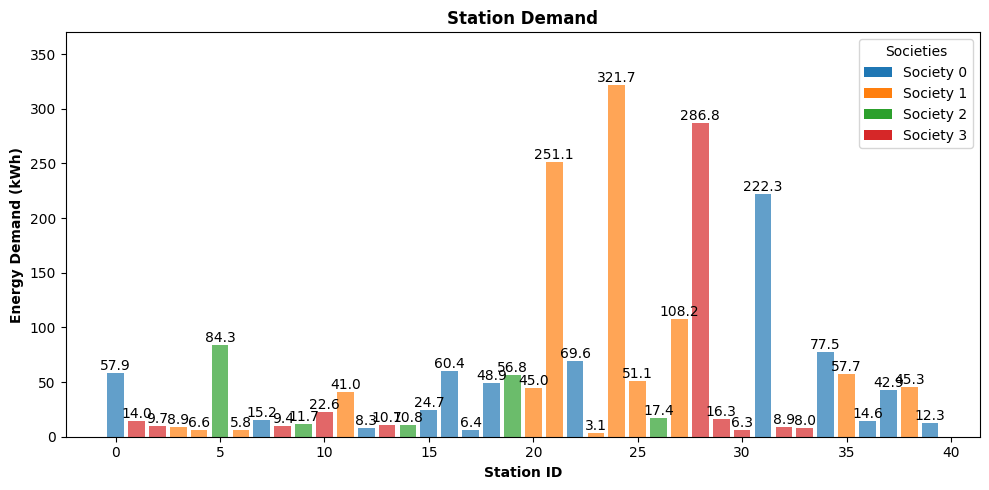

In [75]:
plot_station_demand(greedy_simulation.metrics, societies=societies, figsize=(10, 5))

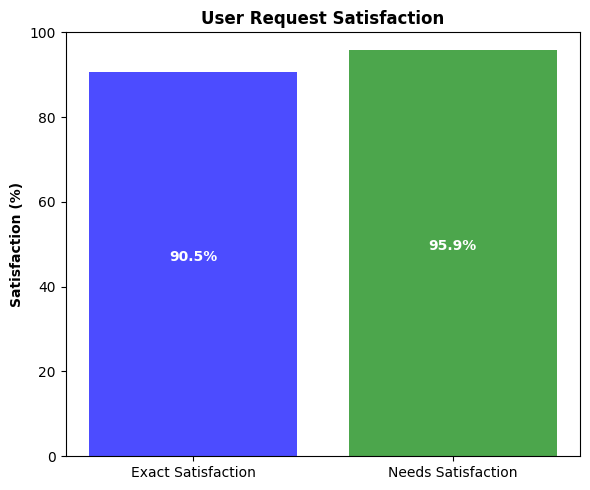

In [76]:
plot_user_satisfaction(greedy_simulation.metrics)

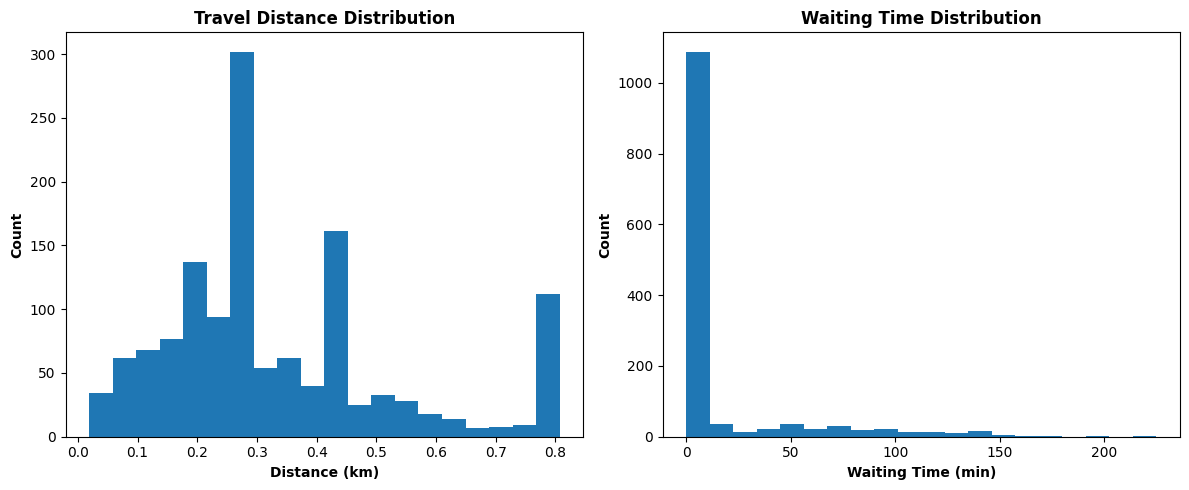

In [77]:
plot_travel_waiting(greedy_simulation.metrics)

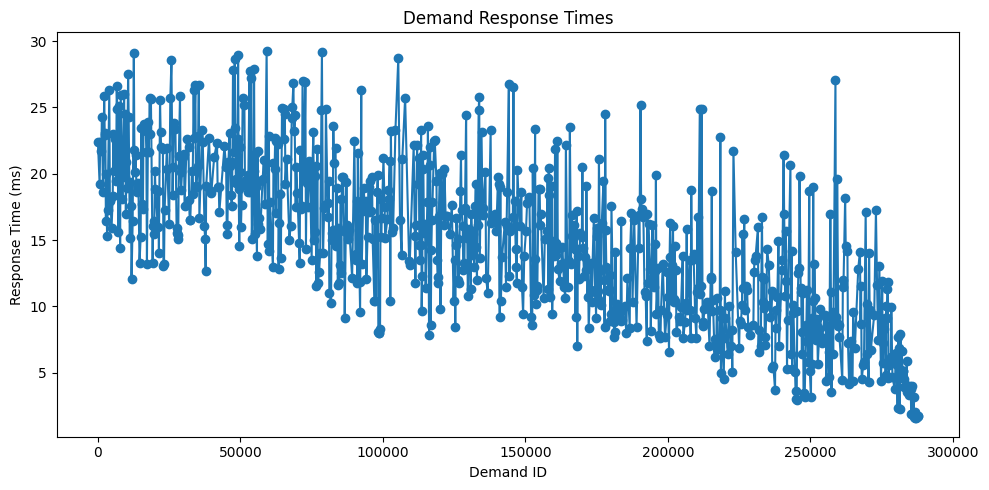

In [78]:
plot_response_times(greedy_simulation.metrics)

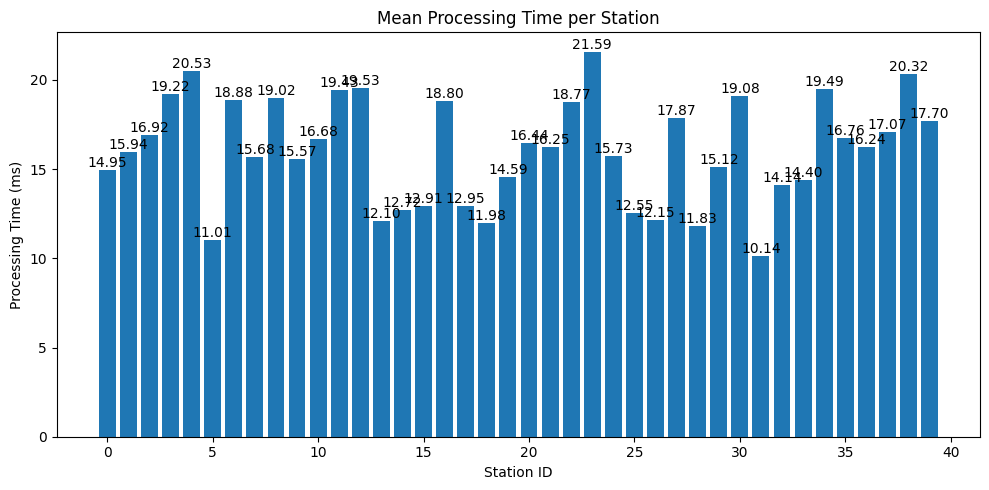

In [79]:
plot_processing_times(greedy_simulation.metrics)

#### **BRAM-EV**

##### *Params*

In [80]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/200cars


##### *Initialisation*

In [81]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [82]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-25 21:54:17.937 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-25 21:54:19.526 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-25 21:54:21.117 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-25 21:54:23.224 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-25 21:54:25.114 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-25 21:54:26.353 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-25 21:54:29.613 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-25 21:54:32.176 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-25 21:54:33.993 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-25 21:54:35.859 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-25 21:54:37.457 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [83]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 8.94 kWh
  Station 1: 6.12 kWh
  Station 2: 135.38 kWh
  Station 3: 50.61 kWh
  Station 4: 54.46 kWh
  Station 5: 10.22 kWh
  Station 6: 7.98 kWh
  Station 7: 33.48 kWh
  Station 8: 115.82 kWh
  Station 9: 12.22 kWh
  Station 10: 65.61 kWh
  Station 11: 86.18 kWh
  Station 12: 7.28 kWh
  Station 13: 19.48 kWh
  Station 14: 62.16 kWh
  Station 15: 14.35 kWh
  Station 16: 27.92 kWh
  Station 17: 11.97 kWh
  Station 18: 15.65 kWh
  Station 19: 232.01 kWh
  Station 20: 42.20 kWh
  Station 21: 10.33 kWh
  Station 22: 7.38 kWh
  Station 23: 18.05 kWh
  Station 24: 7.31 kWh
  Station 25: 53.47 kWh
  Station 26: 22.91 kWh
  Station 27: 14.10 kWh
  Station 28: 88.33 kWh
  Station 29: 215.43 kWh
  Station 30: 110.37 kWh
  Station 31: 6.51 kWh
  Station 32: 17.03 kWh
  Station 33: 59.86 kWh
  Station 34: 111.16 kWh
  Station 35: 213.73 kWh
  Station 36: 30.43 kWh
  Station 37: 171.04 kWh
  Station 38: 41.87 kWh
  Station 

In [84]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

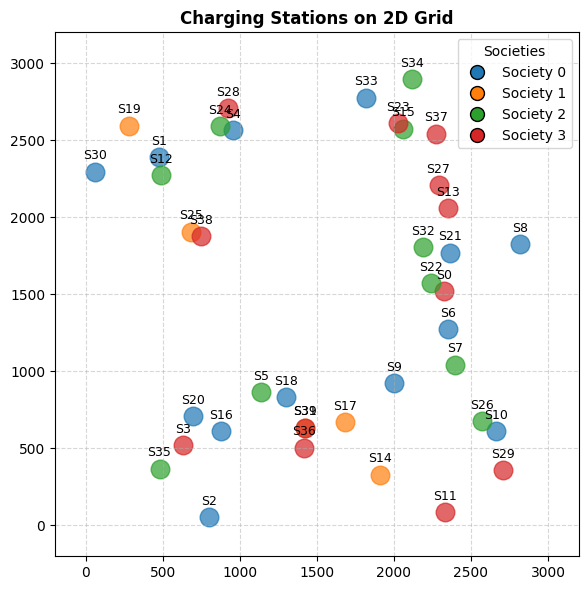

In [85]:
plot_stations_2d(stations, sim_config, figsize=(6, 6), padding=200)

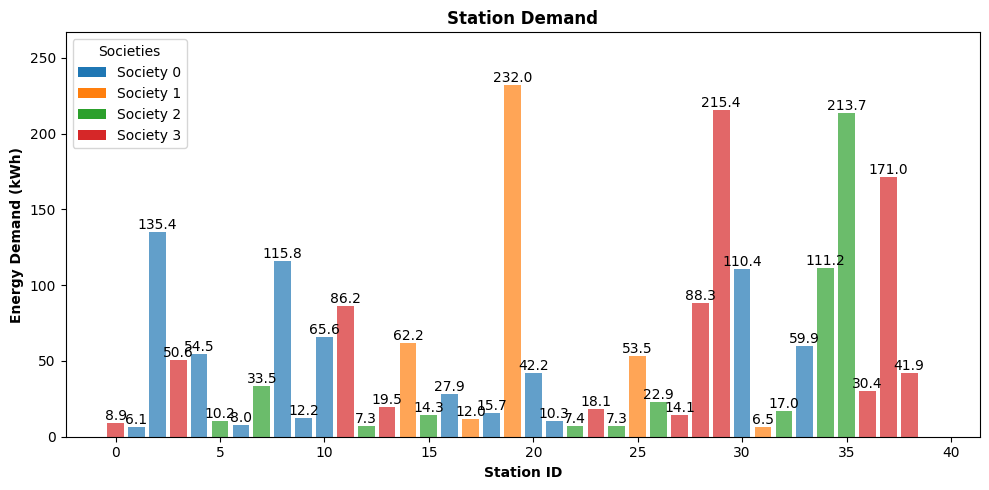

In [86]:
plot_station_demand(simulation.metrics, societies=societies, figsize=(10, 5))

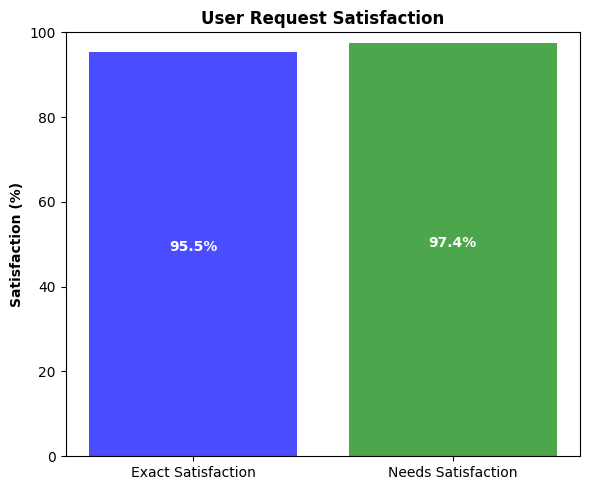

In [87]:
plot_user_satisfaction(simulation.metrics)

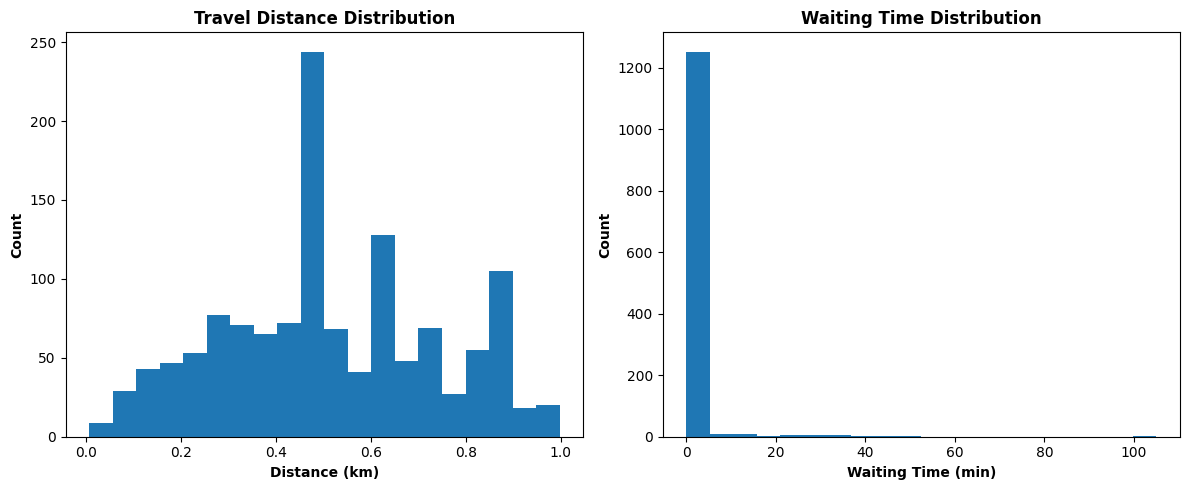

In [88]:
plot_travel_waiting(simulation.metrics)

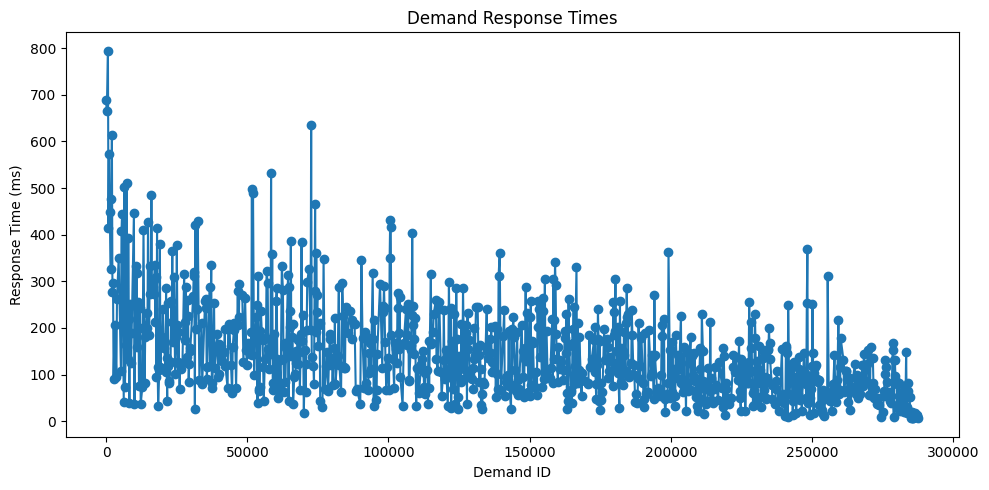

In [89]:
plot_response_times(simulation.metrics)

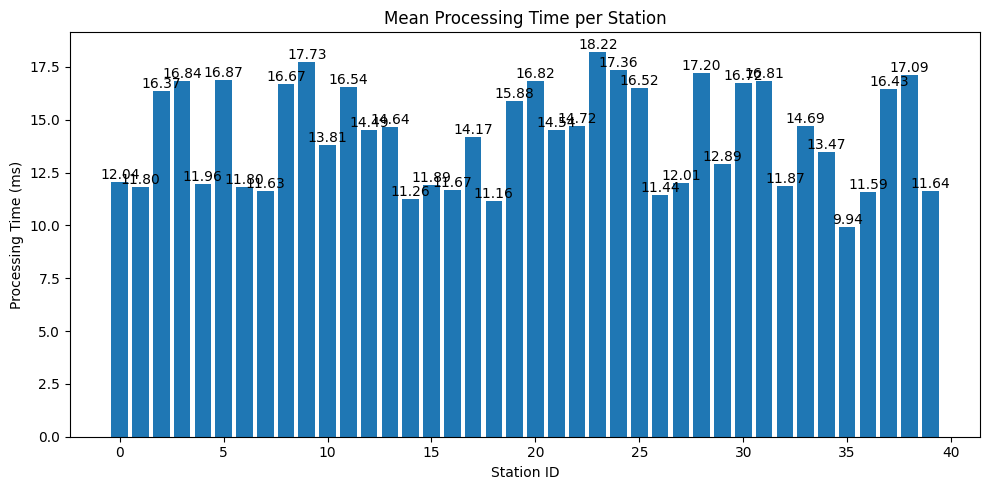

In [90]:
plot_processing_times(simulation.metrics)

#### **COMPARISON**

##### *Params*

In [91]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

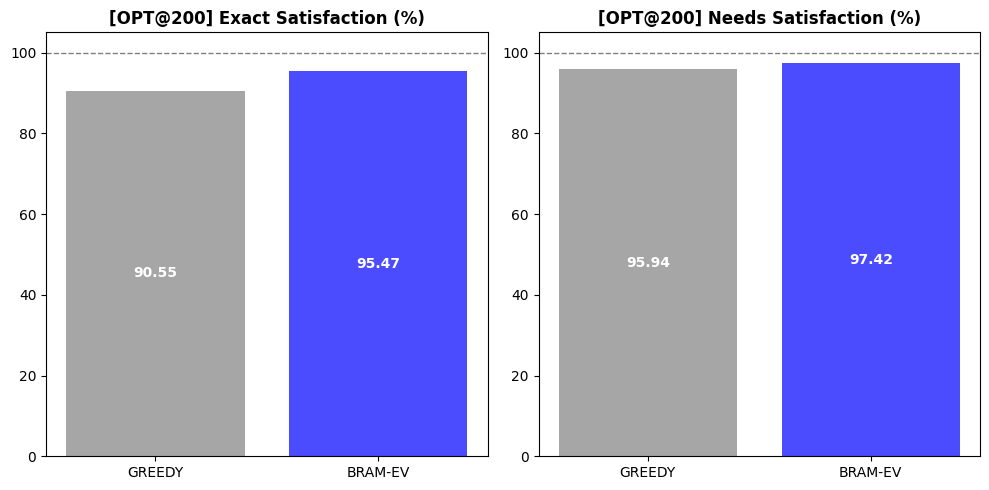

In [92]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

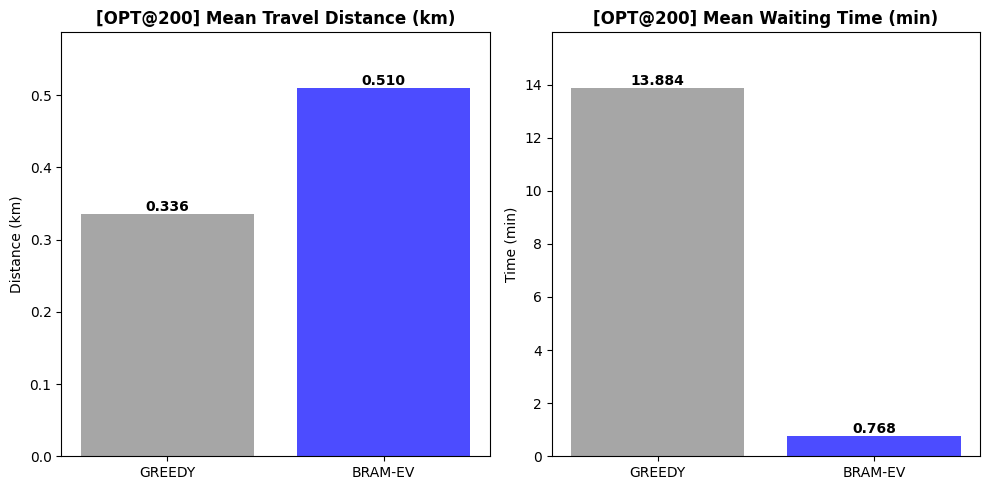

In [93]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

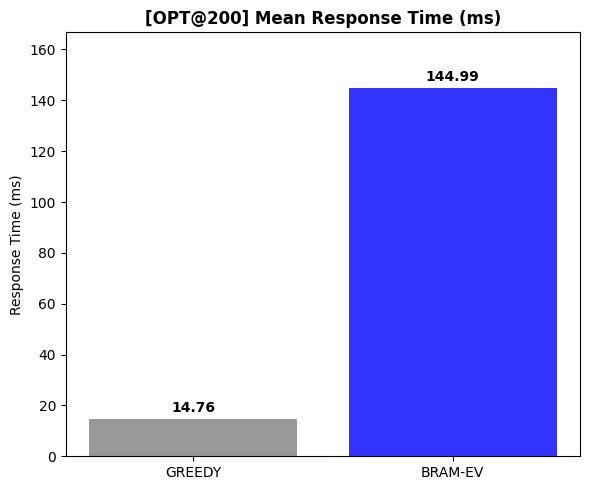

In [94]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@300cars**

#### **CONFIG**

In [95]:
nb_car = 300
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [96]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/300cars


##### *Initialisation*

In [97]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [98]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-25 21:56:37.486 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-25 21:56:37.871 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-25 21:56:38.232 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-25 21:56:38.653 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-25 21:56:39.012 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-25 21:56:39.318 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-25 21:56:39.758 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-25 21:56:40.122 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-25 21:56:40.475 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-25 21:56:40.960 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-25 21:56:41.361 | IN

##### *Metrics*

In [99]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 18.60 kWh
  Station 1: 36.04 kWh
  Station 2: 13.85 kWh
  Station 3: 131.20 kWh
  Station 4: 50.83 kWh
  Station 5: 263.46 kWh
  Station 6: 17.16 kWh
  Station 7: 5.40 kWh
  Station 8: 334.97 kWh
  Station 9: 149.00 kWh
  Station 10: 58.32 kWh
  Station 11: 5.07 kWh
  Station 12: 20.16 kWh
  Station 13: 58.74 kWh
  Station 14: 18.32 kWh
  Station 15: 71.18 kWh
  Station 16: 98.97 kWh
  Station 17: 102.57 kWh
  Station 18: 103.17 kWh
  Station 19: 25.78 kWh
  Station 20: 13.68 kWh
  Station 21: 23.76 kWh
  Station 22: 111.93 kWh
  Station 23: 15.01 kWh
  Station 24: 9.52 kWh
  Station 25: 75.03 kWh
  Station 26: 64.74 kWh
  Station 27: 27.37 kWh
  Station 28: 102.88 kWh
  Station 29: 219.07 kWh
  Station 30: 259.99 kWh
  Station 31: 103.57 kWh
  Station 32: 10.88 kWh
  Station 33: 76.34 kWh
  Station 34: 80.14 kWh
  Station 35: 26.29 kWh
  Station 36: 14.83 kWh
  Station 37: 1.81 kWh
  Station 38: 14.45 kWh
  St

In [100]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

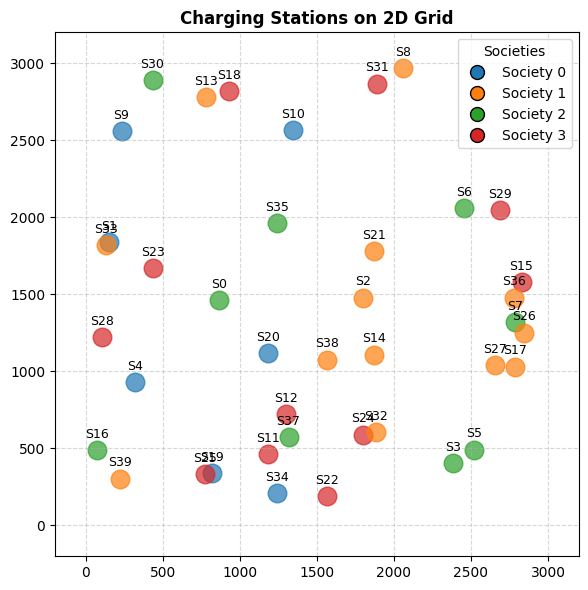

In [101]:
plot_stations_2d(stations, sim_config, figsize=(6, 6), padding=200)

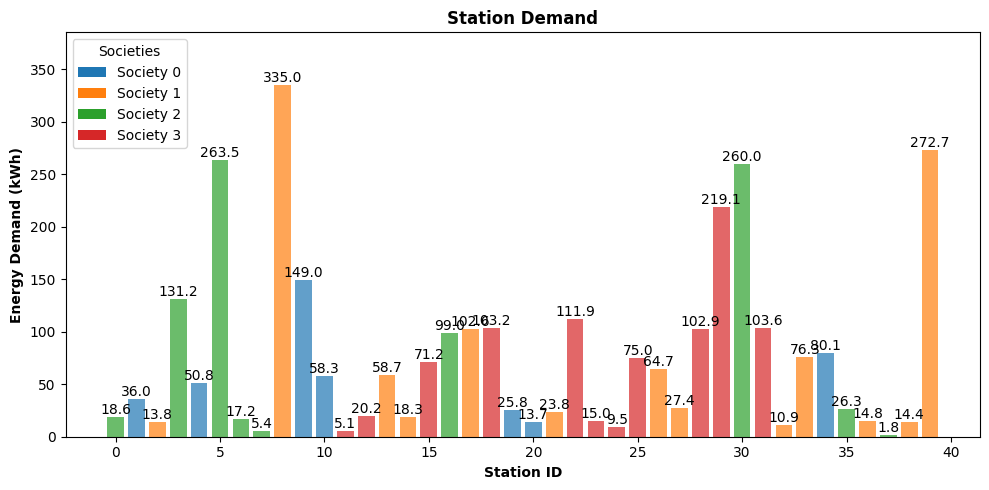

In [102]:
plot_station_demand(greedy_simulation.metrics, societies=societies, figsize=(10, 5))

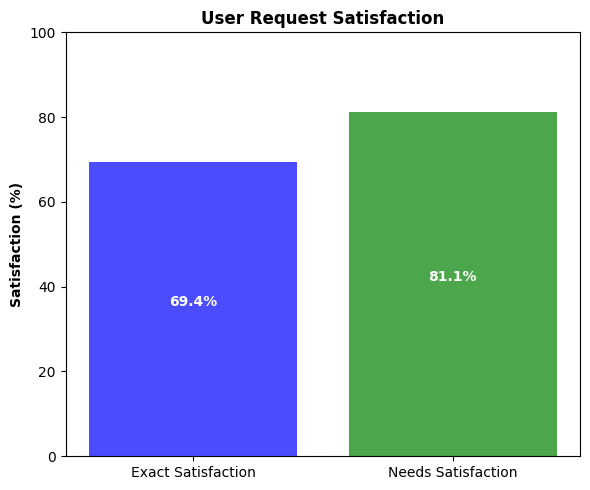

In [103]:
plot_user_satisfaction(greedy_simulation.metrics)

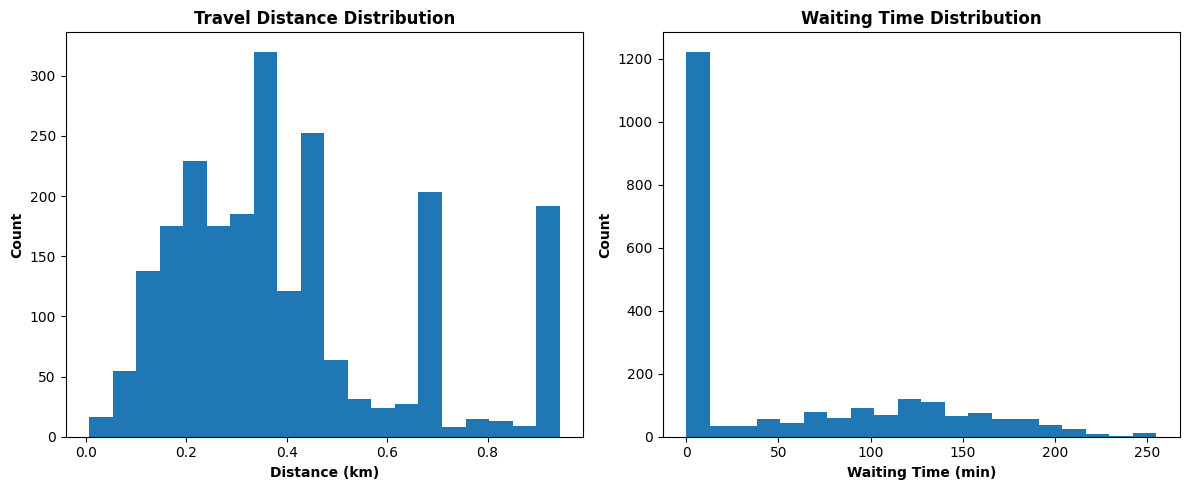

In [104]:
plot_travel_waiting(greedy_simulation.metrics)

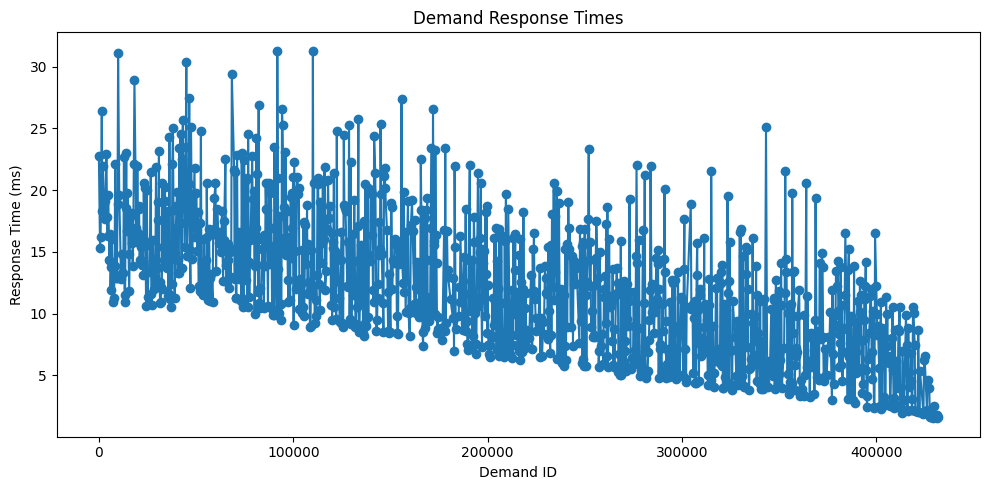

In [105]:
plot_response_times(greedy_simulation.metrics)

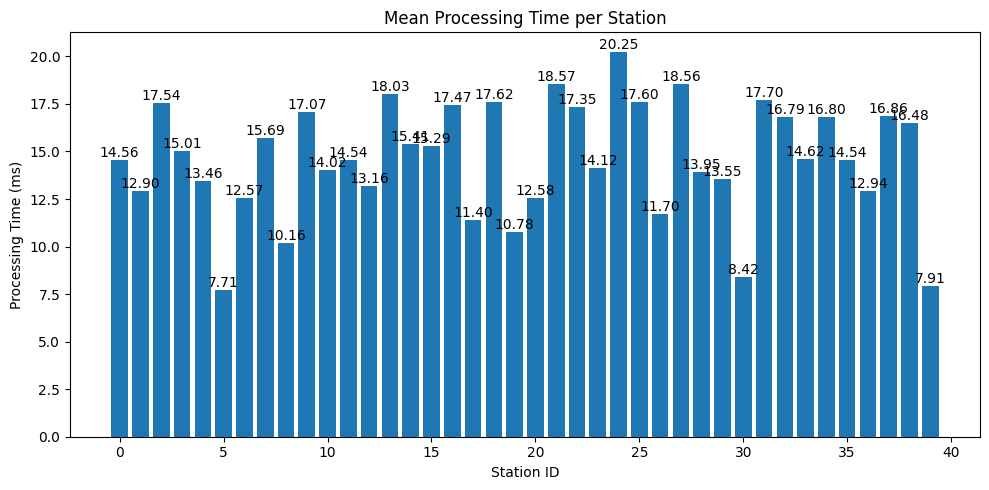

In [106]:
plot_processing_times(greedy_simulation.metrics)

#### **BRAM-EV**

##### *Params*

In [107]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/300cars


##### *Initialisation*

In [108]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [109]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-25 21:57:18.197 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-25 21:57:27.754 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-25 21:57:37.355 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-25 21:57:43.939 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-25 21:57:46.662 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-25 21:57:49.911 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-25 21:57:51.787 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-25 21:57:54.838 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-25 21:57:57.096 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-25 21:57:59.275 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-25 21:58:00.774 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [110]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 123.42 kWh
  Station 1: 31.53 kWh
  Station 2: 21.81 kWh
  Station 3: 100.13 kWh
  Station 4: 38.38 kWh
  Station 5: 13.31 kWh
  Station 6: 26.12 kWh
  Station 7: 219.30 kWh
  Station 8: 24.74 kWh
  Station 9: 106.52 kWh
  Station 10: 36.15 kWh
  Station 11: 169.32 kWh
  Station 12: 8.39 kWh
  Station 13: 20.12 kWh
  Station 14: 74.33 kWh
  Station 15: 18.52 kWh
  Station 16: 282.78 kWh
  Station 17: 20.98 kWh
  Station 18: 29.45 kWh
  Station 19: 57.08 kWh
  Station 20: 188.07 kWh
  Station 21: 133.64 kWh
  Station 22: 34.12 kWh
  Station 23: 245.00 kWh
  Station 24: 16.68 kWh
  Station 25: 230.68 kWh
  Station 26: 32.38 kWh
  Station 27: 110.58 kWh
  Station 28: 129.67 kWh
  Station 29: 54.62 kWh
  Station 30: 69.89 kWh
  Station 31: 15.64 kWh
  Station 32: 24.97 kWh
  Station 33: 76.17 kWh
  Station 34: 13.55 kWh
  Station 35: 133.74 kWh
  Station 36: 39.27 kWh
  Station 37: 197.95 kWh
  Station 38: 26.79 kW

In [111]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

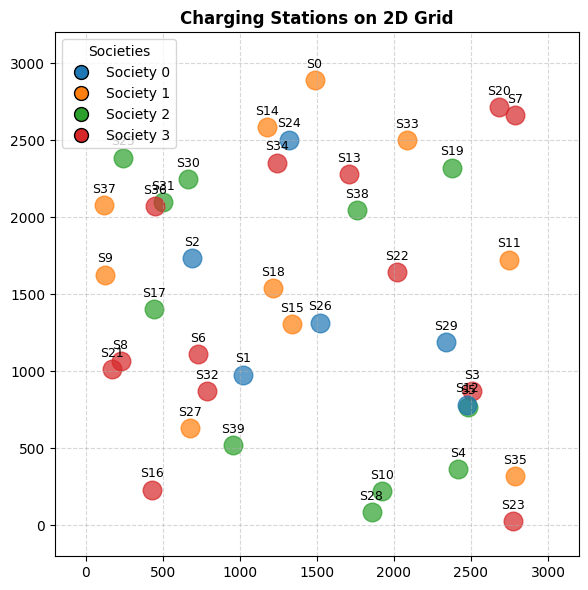

In [112]:
plot_stations_2d(stations, sim_config, figsize=(6, 6), padding=200)

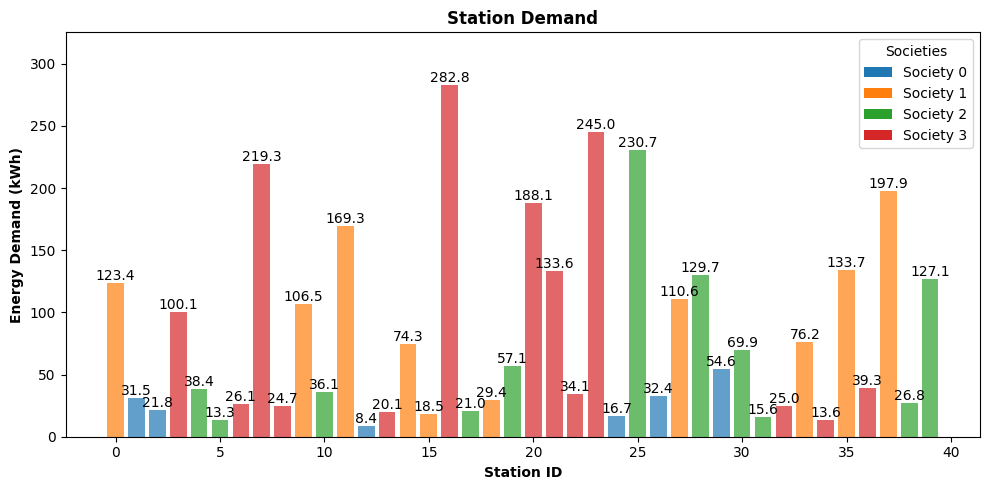

In [113]:
plot_station_demand(simulation.metrics, societies=societies, figsize=(10, 5))

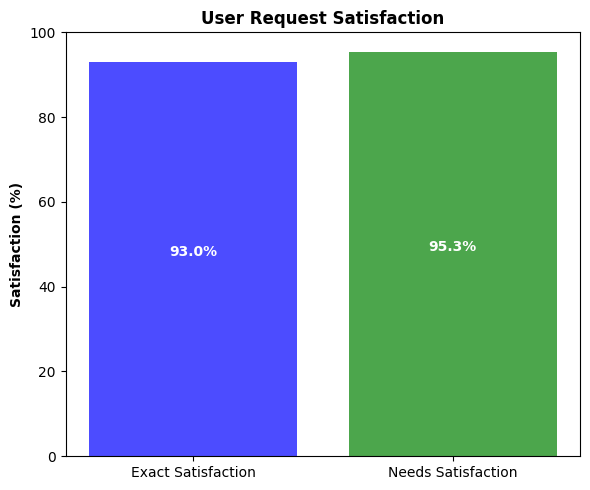

In [114]:
plot_user_satisfaction(simulation.metrics)

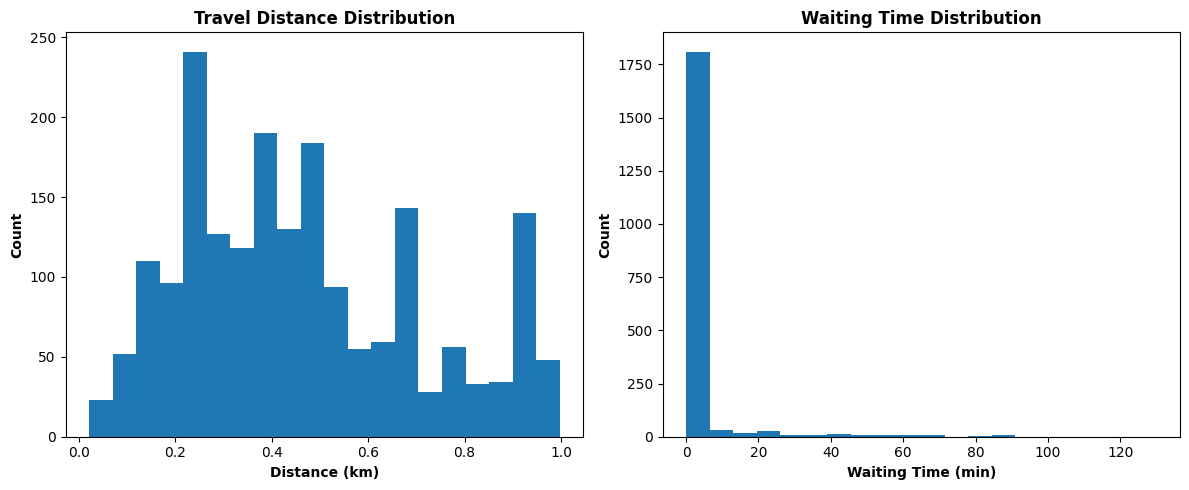

In [115]:
plot_travel_waiting(simulation.metrics)

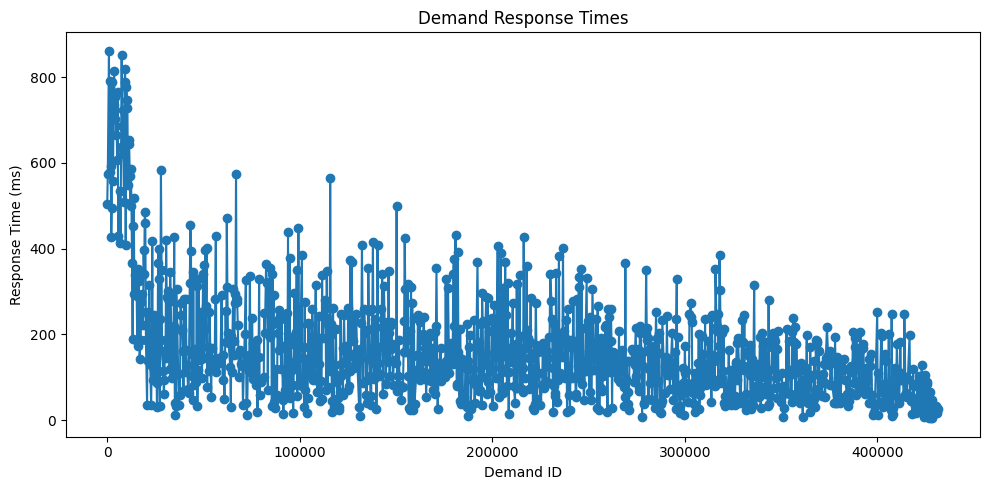

In [116]:
plot_response_times(simulation.metrics)

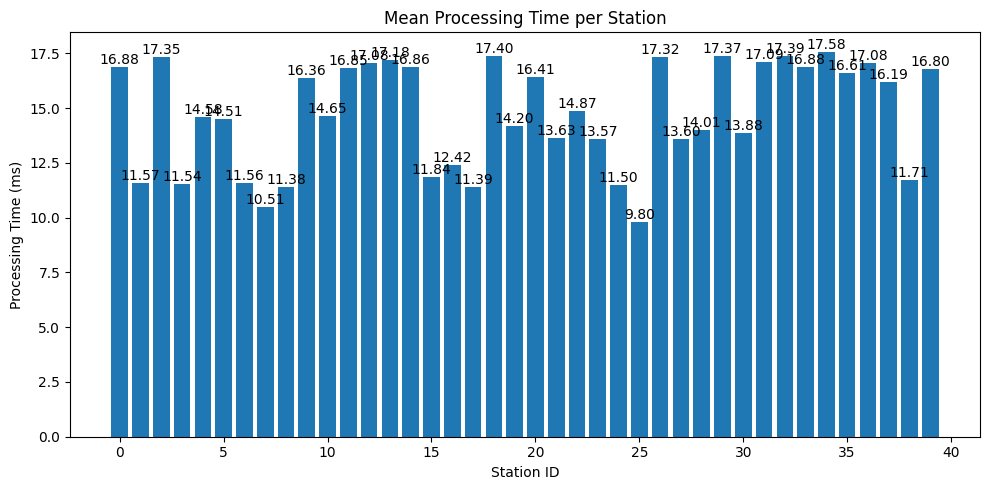

In [117]:
plot_processing_times(simulation.metrics)

#### **COMPARISON**

##### *Params*

In [118]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

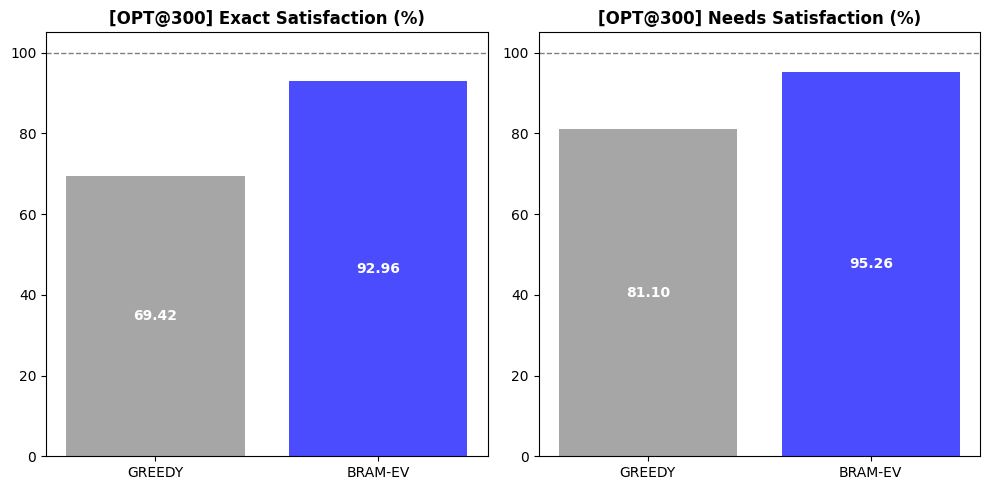

In [119]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

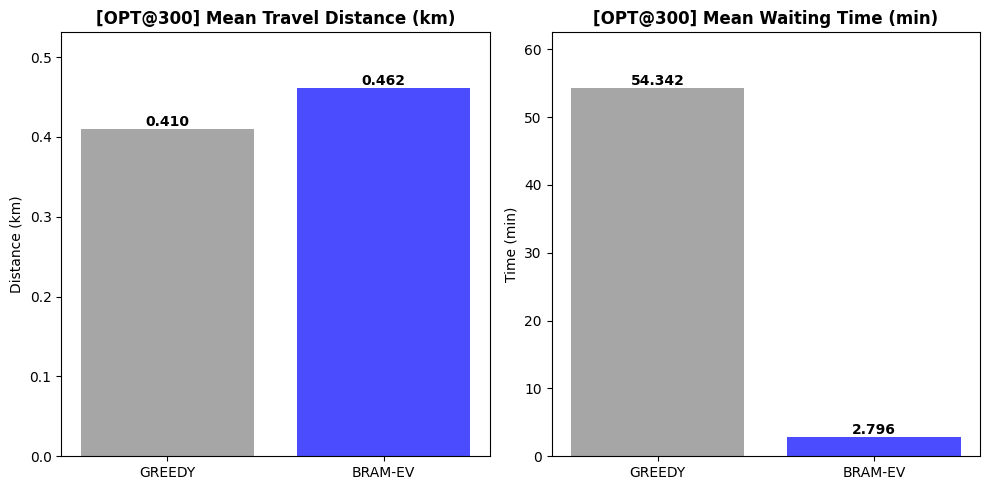

In [120]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

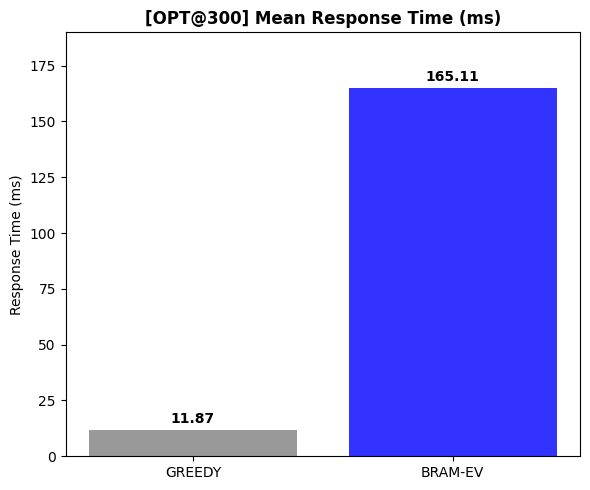

In [121]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

## **COMPARISON**

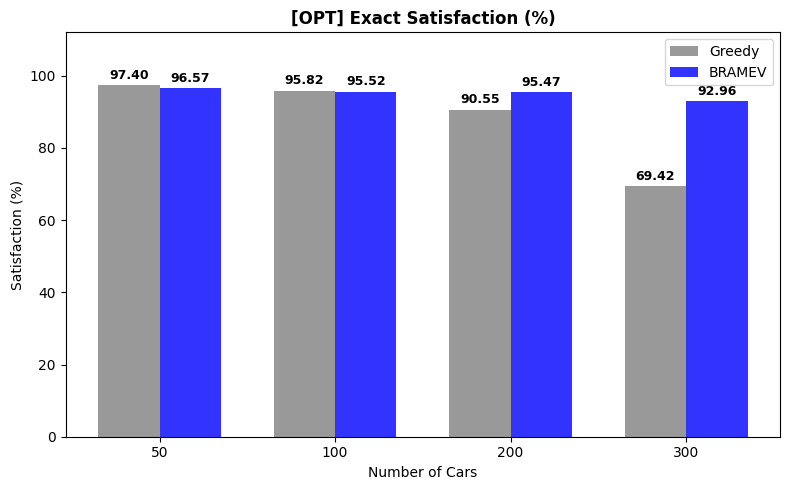

In [122]:
plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

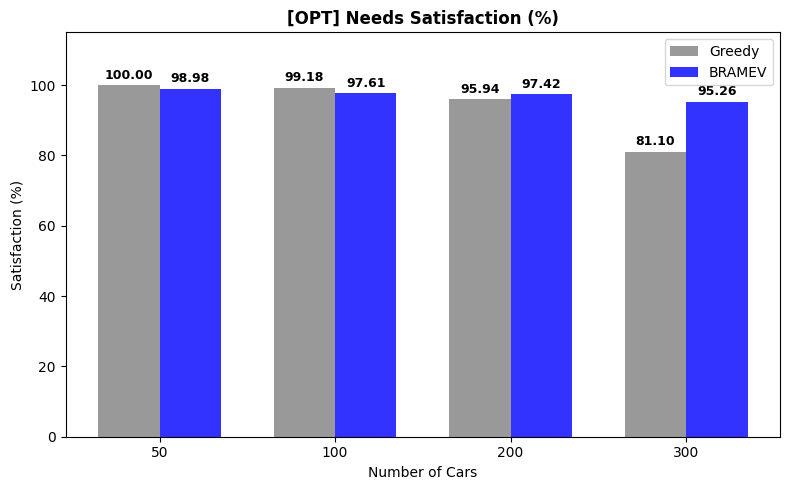

In [123]:
plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

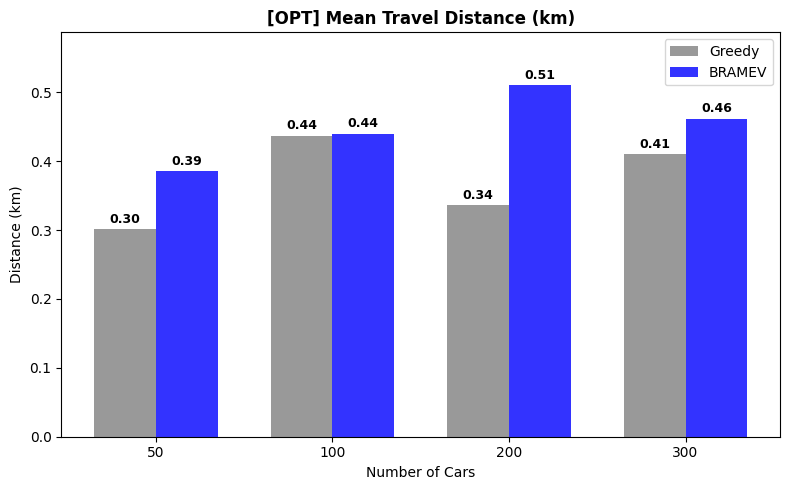

In [124]:
plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


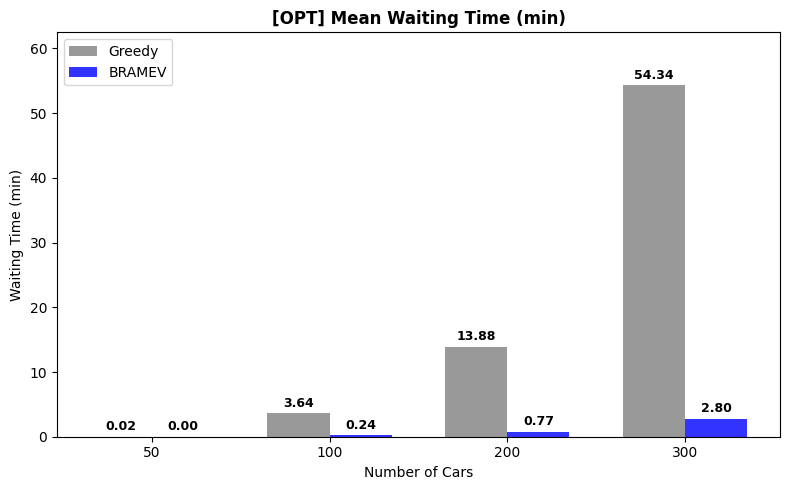

In [125]:
plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


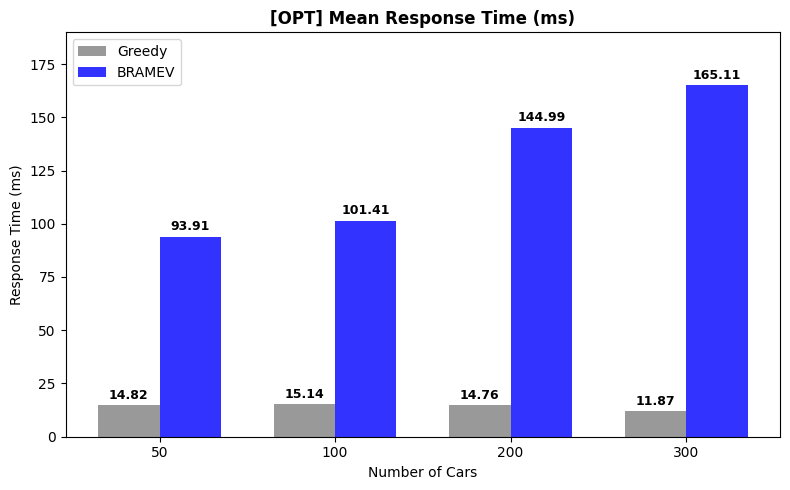

In [126]:
plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)
